In [ ]:
#  Operador forward 3D TRE/ERT 
# =============================================================
# Versión: Junio 2026
# Autora:  Paula Bohorquez
#
# DESCRIPCIÓN
# Implementa el problema directo de tomografía de resistividad
# eléctrica (TRE) 3D en arreglo polo-polo práctico:
#   -∇·(σ ∇φ) = q
#
# CARACTERÍSTICAS TÉCNICAS
# - FV cell-centered, malla tensorial con padding geométrico
# - σ heterogénea, promedio armónico en interfaces
# - BC: Neumann homogénea en z=0, Dirichlet lejano en laterales/fondo
# - Polo-polo PRÁCTICO: B y N remotos finitos dentro del dominio
#   (factor 3.5 × r_AM_max desde el centro del arreglo)
# - Solver robusto: LU con fallback automático a CG precondicionado
# - Factor geométrico exacto del dipolo A-B / M-N
# - Corrección opcional por factor geométrico numérico (rho_a_num)
#
# MODELOS DISPONIBLES (Bloque 3)
# - "homogeneo"      : modelo homogéneo de 700 Ω·m
# - "capas"          : modelo de tres capas
# - "capas_anomalia" : tres capas + anomalía conductiva
#
# CONVENCIÓN DE INDEXACIÓN
#   arr[nx, ny, nz]  con orden Fortran
#   v = arr.ravel(order="F")
#   p = i + nx*j + nx*ny*k
# =============================================================

In [11]:
#%% ------------------------------------------------------------
# BLOQUE 1 — Librerías y configuración
# ------------------------------------------------------------
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import os
import re
import matplotlib as mpl
from matplotlib.colors import LogNorm
import scipy.sparse as sp
import time
import scipy.sparse.linalg as spla
from typing import List, Tuple, Dict
import json
import pandas as pd

np.random.seed(0)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})


Malla tensorial con padding optimizado generada
------------------------------------------------
nx, ny, nz = 86, 86, 56
N total = 414176
Lx, Ly, Lz = 270.00, 270.00, 120.00 m

Zona fina central:
x = [100.00, 170.00] m
y = [100.00, 170.00] m
z = [0.00, 50.00] m

Padding:
n_pad_x = 8 por lado | factor_x = 1.705
n_pad_y = 8 por lado | factor_y = 1.705
n_pad_z_bottom = 6 | factor_z = 2.052

Tamaños de celda:
dx min/max = 1.000 / 41.948 m
dy min/max = 1.000 / 41.948 m
dz min/max = 1.000 / 36.373 m

Centro del dominio: x=135.00 m, y=135.00 m
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_2_malla_padding\bloque2_malla_padding_xz.png
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_2_malla_padding\bloque2_malla_padding_xz.pdf


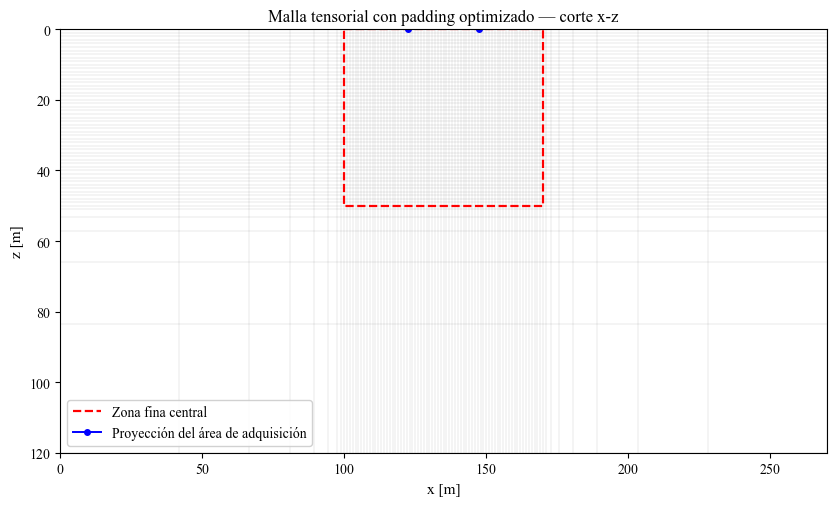

In [12]:
#%% ------------------------------------------------------------
# BLOQUE 2 — Dominio 3D y malla tensorial con padding optimizado
# ------------------------------------------------------------

# ============================================================
# Dimensiones físicas objetivo del dominio
# ============================================================

Lx_target = 270.0   # [m] — ampliado para alojar B/N remotos a 3.5×r_AM_max
Ly_target = 270.0   # [m] — ampliado para alojar B/N remotos a 3.5×r_AM_max
Lz_target = 120.0    # [m]

# ============================================================
# Parámetros de la zona fina central
# ============================================================
# Esta zona contiene el arreglo de electrodos y el modelo de interés.
# Se mantiene con resolución fina de 1 m.

Lx_core = 70.0   # [m]
Ly_core = 70.0   # [m]
Lz_core = 50.0   # [m]

h_core_x = 1.0   # [m]
h_core_y = 1.0   # [m]
h_core_z = 1.0   # [m]

nx_core = int(Lx_core / h_core_x)
ny_core = int(Ly_core / h_core_y)
nz_core = int(Lz_core / h_core_z)

# ============================================================
# Parámetros del padding optimizado
# ============================================================
# Se usan pocas celdas de padding, pero con crecimiento geométrico.
# Esto aleja las fronteras sin aumentar demasiado el número total de celdas.

n_pad_x = 8
n_pad_y = 8
n_pad_z_bottom = 6

# ============================================================
# Funciones auxiliares
# ============================================================

def solve_padding_factor(h0, n_pad, target_length, tol=1e-10, max_iter=100):
    """
    Calcula el factor geométrico f tal que:

        h0 * (1 + f + f^2 + ... + f^(n_pad-1)) = target_length

    Esto permite que el padding tenga una longitud física exacta.
    """
    if n_pad <= 0:
        return 1.0

    min_length = n_pad * h0

    if target_length < min_length:
        raise ValueError(
            f"El padding objetivo ({target_length:.3f} m) es menor que "
            f"la longitud mínima con celdas de {h0:.3f} m ({min_length:.3f} m). "
            "Reduce n_pad o h0."
        )

    if np.isclose(target_length, min_length):
        return 1.0

    def geom_sum(f):
        return h0 * np.sum(f ** np.arange(n_pad))

    f_low = 1.0
    f_high = 1.2

    while geom_sum(f_high) < target_length:
        f_high *= 1.2

    for _ in range(max_iter):
        f_mid = 0.5 * (f_low + f_high)

        if geom_sum(f_mid) < target_length:
            f_low = f_mid
        else:
            f_high = f_mid

        if abs(geom_sum(f_mid) - target_length) < tol:
            break

    return 0.5 * (f_low + f_high)


def geometric_padding_exact(h0, n_pad, target_length):
    """
    Construye una secuencia de padding con crecimiento geométrico
    cuya suma es exactamente target_length.
    """
    if n_pad <= 0:
        return np.array([], dtype=float), 1.0

    factor = solve_padding_factor(h0, n_pad, target_length)
    widths = h0 * factor ** np.arange(n_pad)

    # Corrección mínima por redondeo numérico
    widths *= target_length / np.sum(widths)

    return widths, factor


def build_axis_fixed_total_with_padding(L_total, L_core, h_core, n_pad):
    """
    Construye una dirección con:
    padding izquierdo + zona fina central + padding derecho.

    La longitud total queda exactamente igual a L_total.
    """
    if L_core >= L_total:
        raise ValueError("L_core debe ser menor que L_total.")

    n_core = int(L_core / h_core)
    core = h_core * np.ones(n_core)

    pad_length_each_side = 0.5 * (L_total - L_core)

    pad_right, factor = geometric_padding_exact(
        h_core,
        n_pad,
        pad_length_each_side
    )

    pad_left = pad_right[::-1]

    widths = np.r_[pad_left, core, pad_right]

    edges = np.r_[0.0, np.cumsum(widths)]
    centers = 0.5 * (edges[:-1] + edges[1:])

    core_start = np.sum(pad_left)
    core_end = core_start + np.sum(core)

    return widths, edges, centers, core_start, core_end, factor


def build_depth_fixed_total_with_bottom_padding(L_total, L_core, h_core, n_pad_bottom):
    """
    Construye la dirección z con:
    zona fina desde superficie + padding hacia el fondo.

    La superficie se mantiene en z=0.
    """
    if L_core >= L_total:
        raise ValueError("Lz_core debe ser menor que Lz_target.")

    n_core = int(L_core / h_core)
    core = h_core * np.ones(n_core)

    pad_length_bottom = L_total - L_core

    pad_bottom, factor = geometric_padding_exact(
        h_core,
        n_pad_bottom,
        pad_length_bottom
    )

    widths = np.r_[core, pad_bottom]

    edges = np.r_[0.0, np.cumsum(widths)]
    centers = 0.5 * (edges[:-1] + edges[1:])

    core_start = 0.0
    core_end = np.sum(core)

    return widths, edges, centers, core_start, core_end, factor


# ============================================================
# Construcción de la malla tensorial
# ============================================================

dx, x_edges, x_c, x_core_start, x_core_end, pad_factor_x = build_axis_fixed_total_with_padding(
    Lx_target,
    Lx_core,
    h_core_x,
    n_pad_x
)

dy, y_edges, y_c, y_core_start, y_core_end, pad_factor_y = build_axis_fixed_total_with_padding(
    Ly_target,
    Ly_core,
    h_core_y,
    n_pad_y
)

dz, z_edges, z_c, z_core_start, z_core_end, pad_factor_z = build_depth_fixed_total_with_bottom_padding(
    Lz_target,
    Lz_core,
    h_core_z,
    n_pad_z_bottom
)

nx = len(dx)
ny = len(dy)
nz = len(dz)

Lx = x_edges[-1]
Ly = y_edges[-1]
Lz = z_edges[-1]

N = nx * ny * nz
nxy = nx * ny

# Para mantener compatibilidad con bloques posteriores
hx = dx
hy = dy
hz = dz

extent_xz = [x_edges[0], x_edges[-1], z_edges[-1], z_edges[0]]
extent_xy = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]

# ============================================================
# Coordenadas 3D de centros de celda
# ============================================================

Xc, Yc, Zc = np.meshgrid(x_c, y_c, z_c, indexing="ij")

# ============================================================
# Funciones de indexación compatibles con malla no uniforme
# ============================================================

def coord_to_index(edges, value):
    """
    Convierte una coordenada física en índice de celda para una malla no uniforme.
    """
    idx = np.searchsorted(edges, value, side="right") - 1
    idx = int(np.clip(idx, 0, len(edges) - 2))
    return idx


def ijk_to_p(i, j, k):
    """
    Índice lineal compatible con ravel(order='F'):
    p = i + nx*j + nx*ny*k
    """
    return int(i + nx * j + nx * ny * k)


def p_to_ijk(p):
    """
    Convierte índice lineal p a índices (i,j,k).
    """
    p = int(p)
    k = p // (nx * ny)
    rem = p - k * nx * ny
    j = rem // nx
    i = rem - j * nx
    return i, j, k


def xyz_to_p(x, y, z):
    """
    Convierte coordenadas físicas (x,y,z) a índice lineal de celda.
    Funciona para malla tensorial no uniforme.
    """
    i = coord_to_index(x_edges, x)
    j = coord_to_index(y_edges, y)
    k = coord_to_index(z_edges, z)
    return ijk_to_p(i, j, k)


def p_to_xyz(p):
    """
    Devuelve las coordenadas del centro de celda asociado al índice p.
    """
    i, j, k = p_to_ijk(p)
    return x_c[i], y_c[j], z_c[k]


def vec_to_grid(v):
    """
    Convierte vector de tamaño N a arreglo 3D usando el mismo ordenamiento.
    """
    return np.asarray(v).reshape((nx, ny, nz), order="F")


def grid_to_vec(A):
    """
    Convierte arreglo 3D a vector usando el mismo ordenamiento.
    """
    return np.asarray(A).ravel(order="F")


# Coordenadas por índice lineal
coord_by_p = np.column_stack((
    Xc.ravel(order="F"),
    Yc.ravel(order="F"),
    Zc.ravel(order="F")
))

# ============================================================
# Información de la malla
# ============================================================

print("Malla tensorial con padding optimizado generada")
print("------------------------------------------------")
print(f"nx, ny, nz = {nx}, {ny}, {nz}")
print(f"N total = {N}")
print(f"Lx, Ly, Lz = {Lx:.2f}, {Ly:.2f}, {Lz:.2f} m")
print("")
print("Zona fina central:")
print(f"x = [{x_core_start:.2f}, {x_core_end:.2f}] m")
print(f"y = [{y_core_start:.2f}, {y_core_end:.2f}] m")
print(f"z = [{z_core_start:.2f}, {z_core_end:.2f}] m")
print("")
print("Padding:")
print(f"n_pad_x = {n_pad_x} por lado | factor_x = {pad_factor_x:.3f}")
print(f"n_pad_y = {n_pad_y} por lado | factor_y = {pad_factor_y:.3f}")
print(f"n_pad_z_bottom = {n_pad_z_bottom} | factor_z = {pad_factor_z:.3f}")
print("")
print("Tamaños de celda:")
print(f"dx min/max = {dx.min():.3f} / {dx.max():.3f} m")
print(f"dy min/max = {dy.min():.3f} / {dy.max():.3f} m")
print(f"dz min/max = {dz.min():.3f} / {dz.max():.3f} m")
print("")
print(f"Centro del dominio: x={0.5*Lx:.2f} m, y={0.5*Ly:.2f} m")


# ============================================================
# Visualización y exportación de la malla
# ============================================================

fig_dir_b2 = "figuras_bloque_2_malla_padding"
os.makedirs(fig_dir_b2, exist_ok=True)

SAVE_FIGS_B2 = True
SAVE_PDF_B2 = True
SAVE_PNG_B2 = True
fig_dpi_b2 = 300

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10


def savefig_b2(fig, filename_base):
    if not SAVE_FIGS_B2:
        return

    if SAVE_PNG_B2:
        png_path = os.path.join(fig_dir_b2, filename_base + ".png")
        fig.savefig(
            png_path,
            dpi=fig_dpi_b2,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(png_path)}")

    if SAVE_PDF_B2:
        pdf_path = os.path.join(fig_dir_b2, filename_base + ".pdf")
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(pdf_path)}")


# ============================================================
# Figura 1: malla x-z
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.2))

for xe in x_edges:
    ax.axvline(xe, color="k", linewidth=0.25, alpha=0.25)

for ze in z_edges:
    ax.axhline(ze, color="k", linewidth=0.25, alpha=0.25)

# Zona fina central x-z
ax.plot(
    [x_core_start, x_core_end, x_core_end, x_core_start, x_core_start],
    [z_core_start, z_core_start, z_core_end, z_core_end, z_core_start],
    "r--",
    linewidth=1.6,
    label="Zona fina central"
)

# Área aproximada de adquisición 25 m centrada
acq_size = 25.0
x_acq_min = 0.5 * Lx - 0.5 * acq_size
x_acq_max = 0.5 * Lx + 0.5 * acq_size

ax.plot(
    [x_acq_min, x_acq_max],
    [0.0, 0.0],
    "bo-",
    linewidth=1.4,
    markersize=4,
    label="Proyección del área de adquisición"
)

ax.set_title("Malla tensorial con padding optimizado — corte x-z")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.set_xlim(x_edges[0], x_edges[-1])
ax.set_ylim(z_edges[-1], z_edges[0])
ax.legend(framealpha=0.9)
ax.grid(False)

plt.tight_layout()

savefig_b2(fig, "bloque2_malla_padding_xz")
plt.show()

Modelo homogéneo
----------------
MODEL_TYPE = homogeneo
ρ_hom = 700.00 Ω·m
σ_hom = 0.00142857 S/m
Valores únicos de resistividad en el modelo:
[700.]
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_3_modelo_homogeneo_700ohmm\bloque3_modelo_homogeneo_700ohmm_sigma_rho_xz.png
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_3_modelo_homogeneo_700ohmm\bloque3_modelo_homogeneo_700ohmm_sigma_rho_xz.pdf


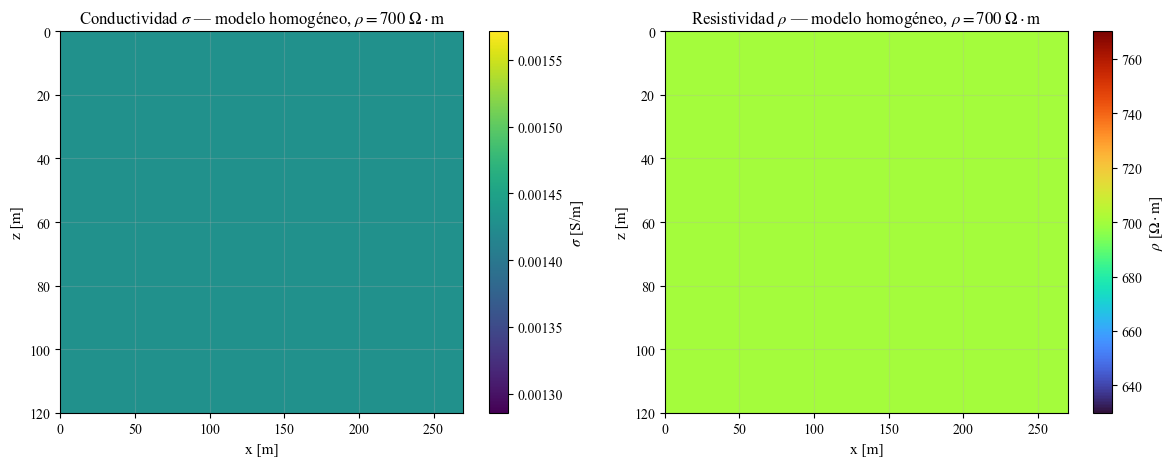

In [13]:
#%% ------------------------------------------------------------
# BLOQUE 3 — Selección del modelo sintético de resistividad + visualización
# ------------------------------------------------------------

# ============================================================
# Selector del modelo sintético
# ============================================================
# Opciones disponibles:
#   "homogeneo"       -> modelo homogéneo de 700 Ω·m
#   "capas"           -> modelo de tres capas
#   "capas_anomalia"  -> modelo de tres capas con anomalía conductiva

MODEL_TYPE = "homogeneo"

valid_models = ["homogeneo", "capas", "capas_anomalia"]

if MODEL_TYPE not in valid_models:
    raise ValueError(
        f"MODEL_TYPE='{MODEL_TYPE}' no es válido. "
        f"Usa una de estas opciones: {valid_models}"
    )

# ============================================================
# Coordenadas 3D de centros de celda
# ============================================================

Xc, Yc, Zc = np.meshgrid(x_c, y_c, z_c, indexing="ij")

# ============================================================
# Parámetros del modelo homogéneo
# ============================================================

rho_hom = 700.0              # Ω·m
sigma_hom = 1.0 / rho_hom   # S/m

# ============================================================
# Parámetros del modelo de tres capas
# ============================================================

rho_layer1 = 1000.0   # Ω·m
rho_layer2 = 600.0    # Ω·m
rho_layer3 = 300.0    # Ω·m

sigma_layer1 = 1.0 / rho_layer1
sigma_layer2 = 1.0 / rho_layer2
sigma_layer3 = 1.0 / rho_layer3

# Interfaces entre capas [m]
z_interface_12 = 2.0
z_interface_23 = 4.0

if z_interface_23 <= z_interface_12:
    raise ValueError("z_interface_23 debe ser mayor que z_interface_12.")

# ============================================================
# Parámetros de la anomalía conductiva
# ============================================================

rho_anomaly = 50.0              # Ω·m
sigma_anomaly = 1.0 / rho_anomaly

# Anomalía centrada en el dominio
anomaly_size_x = 10.0           # [m]
anomaly_size_y = 10.0           # [m]

x_anom_center = 0.5 * Lx
y_anom_center = 0.5 * Ly

x0 = x_anom_center - 0.5 * anomaly_size_x
x1 = x_anom_center + 0.5 * anomaly_size_x

y0 = y_anom_center - 0.5 * anomaly_size_y
y1 = y_anom_center + 0.5 * anomaly_size_y

z0 = 2.0
z1 = 4.0

# ============================================================
# Construcción del modelo seleccionado
# ============================================================

sigma = np.zeros((nx, ny, nz), dtype=float)

if MODEL_TYPE == "homogeneo":

    sigma[:, :, :] = sigma_hom
    model_name = "Modelo homogéneo"
    model_tag = "modelo_homogeneo_700ohmm"
    model_title = r"modelo homogéneo, $\rho=700~\Omega\cdot$m"

elif MODEL_TYPE in ["capas", "capas_anomalia"]:

    mask_layer1 = Zc < z_interface_12
    mask_layer2 = (Zc >= z_interface_12) & (Zc < z_interface_23)
    mask_layer3 = Zc >= z_interface_23

    sigma[mask_layer1] = sigma_layer1
    sigma[mask_layer2] = sigma_layer2
    sigma[mask_layer3] = sigma_layer3

    if MODEL_TYPE == "capas":

        model_name = "Modelo de tres capas"
        model_tag = "modelo_tres_capas"
        model_title = "modelo de tres capas"

    elif MODEL_TYPE == "capas_anomalia":

        mask_anomaly = (
            (Xc >= x0) & (Xc <= x1) &
            (Yc >= y0) & (Yc <= y1) &
            (Zc >= z0) & (Zc <= z1)
        )

        sigma[mask_anomaly] = sigma_anomaly

        model_name = "Modelo de tres capas con anomalía conductiva"
        model_tag = "modelo_tres_capas_anomalia_50ohmm"
        model_title = r"modelo de tres capas con anomalía conductiva de $50~\Omega\cdot$m"

# ============================================================
# Resistividad
# ============================================================

rho = 1.0 / sigma

# ============================================================
# Verificación del modelo
# ============================================================

print(model_name)
print("-" * len(model_name))
print(f"MODEL_TYPE = {MODEL_TYPE}")

if MODEL_TYPE == "homogeneo":

    print(f"ρ_hom = {rho_hom:.2f} Ω·m")
    print(f"σ_hom = {sigma_hom:.8f} S/m")

else:

    print("Capas:")
    print(f"Capa 1: z < {z_interface_12:.2f} m")
    print(f"ρ1 = {rho_layer1:.2f} Ω·m | σ1 = {sigma_layer1:.8f} S/m")

    print(f"Capa 2: {z_interface_12:.2f} m <= z < {z_interface_23:.2f} m")
    print(f"ρ2 = {rho_layer2:.2f} Ω·m | σ2 = {sigma_layer2:.8f} S/m")

    print(f"Capa 3: z >= {z_interface_23:.2f} m")
    print(f"ρ3 = {rho_layer3:.2f} Ω·m | σ3 = {sigma_layer3:.8f} S/m")

    if MODEL_TYPE == "capas_anomalia":
        print("Anomalía conductiva:")
        print(f"x = [{x0:.2f}, {x1:.2f}] m")
        print(f"y = [{y0:.2f}, {y1:.2f}] m")
        print(f"z = [{z0:.2f}, {z1:.2f}] m")
        print(f"ρ_anom = {rho_anomaly:.2f} Ω·m | σ_anom = {sigma_anomaly:.8f} S/m")

print("Valores únicos de resistividad en el modelo:")
print(np.unique(np.round(rho, 3)))

# ============================================================
# Configuración de estilo y exportación de figuras
# ============================================================

fig_dir_b3 = f"figuras_bloque_3_{model_tag}"
os.makedirs(fig_dir_b3, exist_ok=True)

SAVE_FIGS_B3 = True
SAVE_PDF_B3 = True
SAVE_PNG_B3 = True
fig_dpi_b3 = 300

# Fuente Times New Roman
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["figure.titlesize"] = 13

def savefig_b3(fig, filename_base):
    """
    Guarda las figuras del Bloque 3 en PNG y PDF.
    """
    if not SAVE_FIGS_B3:
        return

    if SAVE_PNG_B3:
        png_path = os.path.join(fig_dir_b3, filename_base + ".png")
        fig.savefig(
            png_path,
            dpi=fig_dpi_b3,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(png_path)}")

    if SAVE_PDF_B3:
        pdf_path = os.path.join(fig_dir_b3, filename_base + ".pdf")
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(pdf_path)}")

# ============================================================
# Función auxiliar para graficar cortes
# Compatible con malla uniforme y malla con padding
# ============================================================

def plot_2d_field(ax, field2d, x_edges_plot, y_edges_plot, extent_plot, cmap, label):
    """
    Grafica un campo 2D usando pcolormesh si existen bordes de celda.
    Esto es más correcto para mallas con padding no uniforme.
    Si no hay bordes, usa imshow.
    """
    if x_edges_plot is not None and y_edges_plot is not None:
        im = ax.pcolormesh(
            x_edges_plot,
            y_edges_plot,
            field2d,
            shading="auto",
            cmap=cmap
        )
    else:
        im = ax.imshow(
            field2d,
            extent=extent_plot,
            origin="upper",
            aspect="auto",
            cmap=cmap
        )

    return im

# ============================================================
# Bordes de celda para visualización
# ============================================================

x_edges_plot = globals().get("x_edges", None)
y_edges_plot = globals().get("y_edges", None)
z_edges_plot = globals().get("z_edges", None)

# Fallback para malla uniforme si no existen x_edges, y_edges, z_edges
if x_edges_plot is None:
    x_edges_plot = np.linspace(0.0, Lx, nx + 1)

if y_edges_plot is None:
    y_edges_plot = np.linspace(0.0, Ly, ny + 1)

if z_edges_plot is None:
    z_edges_plot = np.linspace(0.0, Lz, nz + 1)

extent_xz = [x_edges_plot[0], x_edges_plot[-1], z_edges_plot[-1], z_edges_plot[0]]
extent_xy = [x_edges_plot[0], x_edges_plot[-1], y_edges_plot[0], y_edges_plot[-1]]

# ============================================================
# Corte x-z en y = Ly/2
# ============================================================

iy_mid = int(np.argmin(np.abs(y_c - 0.5 * Ly)))

sigma_xz = sigma[:, iy_mid, :].T
rho_xz   = rho[:,   iy_mid, :].T

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

im0 = ax[0].pcolormesh(
    x_edges_plot,
    z_edges_plot,
    sigma_xz,
    shading="auto",
    cmap="viridis"
)

ax[0].set_title(rf"Conductividad $\sigma$ — {model_title}")
ax[0].set_xlabel("x [m]")
ax[0].set_ylabel("z [m]")
ax[0].invert_yaxis()

cbar0 = fig.colorbar(im0, ax=ax[0])
cbar0.set_label(r"$\sigma$ [S/m]")

im1 = ax[1].pcolormesh(
    x_edges_plot,
    z_edges_plot,
    rho_xz,
    shading="auto",
    cmap="turbo"
)

ax[1].set_title(rf"Resistividad $\rho$ — {model_title}")
ax[1].set_xlabel("x [m]")
ax[1].set_ylabel("z [m]")
ax[1].invert_yaxis()

cbar1 = fig.colorbar(im1, ax=ax[1])
cbar1.set_label(r"$\rho$ [$\Omega\cdot$m]")

# Interfaces de capas
if MODEL_TYPE in ["capas", "capas_anomalia"]:

    for axi in ax:
        axi.axhline(
            z_interface_12,
            color="k",
            linestyle="--",
            linewidth=1.1,
            label="Interfaz 1-2"
        )

        axi.axhline(
            z_interface_23,
            color="k",
            linestyle=":",
            linewidth=1.1,
            label="Interfaz 2-3"
        )

    ax[0].legend(framealpha=0.9)

plt.tight_layout()

savefig_b3(
    fig,
    f"bloque3_{model_tag}_sigma_rho_xz"
)

plt.show()



In [14]:
# ============================================================
# Bloque 4 — Ensamble FV de A(sigma) con frontera tipo semiespacio
# Compatible con malla uniforme y malla tensorial con padding
# ============================================================

# ============================================================
# Funciones auxiliares de indexación
# ============================================================

def grid_to_vec(arr3d: np.ndarray) -> np.ndarray:
    """
    Convierte un arreglo 3D con forma (nx, ny, nz) a vector 1D
    usando orden Fortran.
    """
    return np.asarray(arr3d).ravel(order="F")


def vec_to_grid(vec: np.ndarray) -> np.ndarray:
    """
    Convierte un vector 1D a arreglo 3D con forma (nx, ny, nz)
    usando el mismo orden Fortran.
    """
    return np.asarray(vec).reshape((nx, ny, nz), order="F")


def ijk_to_p(i: int, j: int, k: int) -> int:
    """
    Índice lineal compatible con ravel(order='F'):

        p = i + nx*j + nx*ny*k
    """
    return int(i + nx * j + nx * ny * k)


def p_to_ijk(p: int):
    """
    Convierte índice lineal p a índices i, j, k.
    """
    p = int(p)
    k = p // (nx * ny)
    r = p - k * nx * ny
    j = r // nx
    i = r - j * nx
    return i, j, k


# ============================================================
# Función auxiliar para tamaños de celda
# ============================================================

def get_width_array(name_array, name_scalar, n, direction_name):
    """
    Devuelve un arreglo de tamaños de celda para una dirección.

    Prioridad:
    1. Si existe dx, dy o dz, usa esos arreglos.
    2. Si no existen, usa hx, hy o hz.
    3. Si hx, hy o hz son escalares, construye un arreglo uniforme.

    Esto permite que el ensamble funcione tanto con malla uniforme
    como con malla tensorial con padding.
    """
    if name_array in globals():
        val = globals()[name_array]
    elif name_scalar in globals():
        val = globals()[name_scalar]
    else:
        raise NameError(
            f"No se encontró {name_array} ni {name_scalar} "
            f"para la dirección {direction_name}."
        )

    arr = np.asarray(val, dtype=float)

    if arr.ndim == 0:
        arr = np.full(n, float(arr), dtype=float)

    if len(arr) != n:
        raise ValueError(
            f"El arreglo de tamaños en {direction_name} debe tener longitud {n}, "
            f"pero tiene longitud {len(arr)}."
        )

    if np.any(arr <= 0):
        raise ValueError(
            f"Todos los tamaños de celda en la dirección {direction_name} "
            "deben ser positivos."
        )

    return arr


# ============================================================
# Condiciones de frontera
# ============================================================
# "semispace": superficie z=0 con Neumann homogénea, laterales y fondo
#              con Dirichlet lejano φ=0 mediante ghost cells.
# "neumann":   Neumann homogénea en todas las fronteras. Requiere gauge.

BOUNDARY_MODE = "semispace"
USE_GAUGE = (BOUNDARY_MODE == "neumann")


def assemble_A_FV(
    sigma3d: np.ndarray,
    eps: float = 1e-12,
    boundary_mode: str = BOUNDARY_MODE
) -> sp.csr_matrix:
    """
    Ensamble por volúmenes finitos cell-centered:

        Σ_faces G_f (φ_p - φ_n) = b_p

    Para malla no uniforme, la conductancia interna entre dos celdas
    se calcula a partir de resistencias de media celda:

        G = Área / (d_p/(2σ_p) + d_n/(2σ_n))

    donde d_p y d_n son los tamaños locales de celda en la dirección
    normal a la cara.

    boundary_mode = "semispace":
        - z = 0: Neumann homogénea, J·n = 0.
        - x = 0, x = Lx, y = 0, y = Ly, z = Lz:
          Dirichlet lejano φ = 0 usando ghost cells a media celda.

    boundary_mode = "neumann":
        - Neumann homogénea en todas las fronteras.
        - Requiere gauge para eliminar la singularidad.
    """

    sigma3d = np.asarray(sigma3d, dtype=float)

    if sigma3d.shape != (nx, ny, nz):
        raise ValueError(
            f"sigma3d debe tener forma ({nx}, {ny}, {nz}), "
            f"pero tiene forma {sigma3d.shape}."
        )

    if np.any(~np.isfinite(sigma3d)):
        raise ValueError("sigma3d contiene valores no finitos.")

    if np.any(sigma3d <= 0):
        raise ValueError("sigma3d debe contener conductividades positivas.")

    # ------------------------------------------------------------
    # Tamaños de celda
    # ------------------------------------------------------------

    dxv = get_width_array("dx", "hx", nx, "x")
    dyv = get_width_array("dy", "hy", ny, "y")
    dzv = get_width_array("dz", "hz", nz, "z")

    # Conductividad mínima para evitar divisiones por cero
    sig = np.maximum(sigma3d, eps)

    # ------------------------------------------------------------
    # Áreas de caras internas
    # ------------------------------------------------------------

    # Cara normal a x: área = dy * dz
    area_x = dyv[None, :, None] * dzv[None, None, :]        # (1, ny, nz)

    # Cara normal a y: área = dx * dz
    area_y = dxv[:, None, None] * dzv[None, None, :]        # (nx, 1, nz)

    # Cara normal a z: área = dx * dy
    area_z = dxv[:, None, None] * dyv[None, :, None]        # (nx, ny, 1)

    # ------------------------------------------------------------
    # Conductancias internas en x
    # ------------------------------------------------------------
    # Entre celdas i e i+1:
    #
    # Gx = Área / (dx_i/(2σ_i) + dx_{i+1}/(2σ_{i+1}))

    Rx = (
        0.5 * dxv[:-1, None, None] / sig[:-1, :, :] +
        0.5 * dxv[1:,  None, None] / sig[1:,  :, :]
    )

    Gx_face = area_x / Rx    # (nx-1, ny, nz)

    # ------------------------------------------------------------
    # Conductancias internas en y
    # ------------------------------------------------------------

    Ry = (
        0.5 * dyv[None, :-1, None] / sig[:, :-1, :] +
        0.5 * dyv[None, 1:,  None] / sig[:, 1:,  :]
    )

    Gy_face = area_y / Ry    # (nx, ny-1, nz)

    # ------------------------------------------------------------
    # Conductancias internas en z
    # ------------------------------------------------------------

    Rz = (
        0.5 * dzv[None, None, :-1] / sig[:, :, :-1] +
        0.5 * dzv[None, None, 1:]  / sig[:, :, 1:]
    )

    Gz_face = area_z / Rz    # (nx, ny, nz-1)

    # ------------------------------------------------------------
    # Inicializar conductancias internas por dirección
    # ------------------------------------------------------------

    Gxp = np.zeros_like(sigma3d)
    Gxm = np.zeros_like(sigma3d)

    Gyp = np.zeros_like(sigma3d)
    Gym = np.zeros_like(sigma3d)

    Gzp = np.zeros_like(sigma3d)
    Gzm = np.zeros_like(sigma3d)

    # Caras internas reales
    Gxp[:-1, :, :] = Gx_face
    Gxm[1:,  :, :] = Gx_face

    Gyp[:, :-1, :] = Gy_face
    Gym[:, 1:,  :] = Gy_face

    Gzp[:, :, :-1] = Gz_face
    Gzm[:, :, 1:]  = Gz_face

    # ------------------------------------------------------------
    # Conductancias de frontera
    # ------------------------------------------------------------
    # IMPORTANTE:
    # Las conductancias Dirichlet se almacenan en Gbc y entran SOLO
    # en la diagonal principal. No deben aparecer en las diagonales
    # fuera de la principal, porque no conectan dos celdas reales.
    # ------------------------------------------------------------

    Gbc = np.zeros_like(sigma3d)

    if boundary_mode == "semispace":

        # Dirichlet lejano φ=0 en laterales y fondo.
        # Ghost cell a media celda:
        #
        # G_D = σ_c * Área_f / (h_c/2)
        #
        # Como φ_D = 0, el término G_D(φ_p - φ_D)
        # contribuye únicamente a la diagonal principal.

        # x = 0
        area_x_boundary = dyv[:, None] * dzv[None, :]       # (ny, nz)
        Gbc[0, :, :] += sig[0, :, :] * area_x_boundary / (0.5 * dxv[0])

        # x = Lx
        Gbc[-1, :, :] += sig[-1, :, :] * area_x_boundary / (0.5 * dxv[-1])

        # y = 0
        area_y_boundary = dxv[:, None] * dzv[None, :]       # (nx, nz)
        Gbc[:, 0, :] += sig[:, 0, :] * area_y_boundary / (0.5 * dyv[0])

        # y = Ly
        Gbc[:, -1, :] += sig[:, -1, :] * area_y_boundary / (0.5 * dyv[-1])

        # z = Lz, fondo
        area_z_boundary = dxv[:, None] * dyv[None, :]       # (nx, ny)
        Gbc[:, :, -1] += sig[:, :, -1] * area_z_boundary / (0.5 * dzv[-1])

        # z = 0, superficie:
        # Neumann homogénea. No se agrega conductancia.
        # Esto representa ausencia de flujo hacia el aire.

    elif boundary_mode == "neumann":

        # Neumann homogénea en todas las fronteras.
        # No se agregan conductancias de frontera.
        pass

    else:
        raise ValueError("boundary_mode debe ser 'semispace' o 'neumann'.")

    # ------------------------------------------------------------
    # Vectorizar conductancias
    # ------------------------------------------------------------

    Gxp_v = grid_to_vec(Gxp)
    Gxm_v = grid_to_vec(Gxm)

    Gyp_v = grid_to_vec(Gyp)
    Gym_v = grid_to_vec(Gym)

    Gzp_v = grid_to_vec(Gzp)
    Gzm_v = grid_to_vec(Gzm)

    Gbc_v = grid_to_vec(Gbc)

    # ------------------------------------------------------------
    # Diagonal principal
    # ------------------------------------------------------------
    # Incluye:
    # - conductancias internas hacia celdas vecinas
    # - conductancias de frontera Dirichlet, solo en la diagonal

    d0 = (
        Gxp_v + Gxm_v +
        Gyp_v + Gym_v +
        Gzp_v + Gzm_v +
        Gbc_v
    )

    # ------------------------------------------------------------
    # Diagonales fuera de la principal
    # ------------------------------------------------------------
    # Usan únicamente conductancias internas.
    # Las fronteras Dirichlet NO aparecen aquí.

    d_p1   = -Gxp_v[:-1]
    d_m1   = -Gxm_v[1:]

    d_pnx  = -Gyp_v[:-nx]
    d_mnx  = -Gym_v[nx:]

    d_pnxy = -Gzp_v[:-nxy]
    d_mnxy = -Gzm_v[nxy:]

    A = sp.diags(
        diagonals=[
            d_mnxy,
            d_mnx,
            d_m1,
            d0,
            d_p1,
            d_pnx,
            d_pnxy
        ],
        offsets=[
            -nxy,
            -nx,
            -1,
            0,
            1,
            nx,
            nxy
        ],
        shape=(N, N),
        format="csr"
    )

    return A


# ============================================================
# Ensamble de la matriz del operador
# ============================================================

A = assemble_A_FV(sigma)

dxv_test = get_width_array("dx", "hx", nx, "x")
dyv_test = get_width_array("dy", "hy", ny, "y")
dzv_test = get_width_array("dz", "hz", nz, "z")

print("A:", A.shape, "| nnz =", A.nnz)
print("boundary_mode =", BOUNDARY_MODE, "| USE_GAUGE =", USE_GAUGE)
print(
    "dx min/max =",
    f"{dxv_test.min():.3f}/{dxv_test.max():.3f} m |",
    "dy min/max =",
    f"{dyv_test.min():.3f}/{dyv_test.max():.3f} m |",
    "dz min/max =",
    f"{dzv_test.min():.3f}/{dzv_test.max():.3f} m"
)

# ============================================================
# Diagnóstico básico del operador ensamblado
# ============================================================

diag_A = A.diagonal()

print("")
print("Diagnóstico básico de A")
print("-----------------------")
print(f"Diagonal mínima: {diag_A.min():.6e}")
print(f"Diagonal máxima: {diag_A.max():.6e}")
print(f"Valores no finitos en A.data: {np.sum(~np.isfinite(A.data))}")

if np.any(diag_A <= 0):
    print("ADVERTENCIA: existen valores no positivos en la diagonal de A.")
else:
    print("Diagonal positiva: OK")

# Revisión ligera de simetría.
# Para matrices grandes, esta operación puede tomar algunos segundos.
CHECK_SYMMETRY_B4 = True

if CHECK_SYMMETRY_B4:
    asym = A - A.T
    asym_norm = np.linalg.norm(asym.data) if asym.nnz > 0 else 0.0
    A_norm = np.linalg.norm(A.data)
    rel_asym = asym_norm / (A_norm + 1e-30)

    print(f"Asimetría relativa ||A-A.T||/||A|| = {rel_asym:.3e}")

    if rel_asym < 1e-12:
        print("Simetría de A: OK")
    else:
        print("ADVERTENCIA: A no parece ser simétrica dentro de la tolerancia.")

A: (414176, 414176) | nnz = 2865176
boundary_mode = semispace | USE_GAUGE = False
dx min/max = 1.000/41.948 m | dy min/max = 1.000/41.948 m | dz min/max = 1.000/36.373 m

Diagnóstico básico de A
-----------------------
Diagonal mínima: 6.397925e-03
Diagonal máxima: 5.036760e+00
Valores no finitos en A.data: 0
Diagonal positiva: OK
Asimetría relativa ||A-A.T||/||A|| = 0.000e+00
Simetría de A: OK


In [15]:
#%% ------------------------------------------------------------
# BLOQUE 5 — Preparación del operador o diagnóstico de potencial
# ------------------------------------------------------------
# ============================================================
# Selector de ejecución del Bloque 5
# ============================================================
# Opciones:
#   "preparacion" -> solo construye A_gauge, ref_p y funciones necesarias.
#                   Es lo recomendado antes de correr el Bloque 7.
#
#   "completo"    -> además resuelve un caso fuente-sumidero A-B y grafica φ.
#                   Úsalo solo como diagnóstico visual.

B5_MODE = "preparacion"

valid_b5_modes = ["preparacion", "completo"]

if B5_MODE not in valid_b5_modes:
    raise ValueError(
        f"B5_MODE='{B5_MODE}' no es válido. "
        f"Usa una de estas opciones: {valid_b5_modes}"
    )

# Solver para el modo completo:
#   "cg"     -> iterativo, recomendado para diagnóstico rápido.
#   "direct" -> spsolve, puede ser muy costoso en mallas 3D grandes.

B5_SOLVER = "cg"


# ============================================================
# Construcción del término fuente RHS
# ============================================================

def build_rhs_current_pair(p_src: int, p_snk: int, I: float) -> np.ndarray:
    """
    Construye el vector fuente para un par fuente-sumidero A-B.
    """
    b = np.zeros(N, dtype=float)
    b[int(p_src)] = +I
    b[int(p_snk)] = -I
    return b


# ============================================================
# Gauge condicional
# ============================================================

idx = ijk_to_p

def apply_gauge_to_A(A_csr: sp.csr_matrix, ref_p: int) -> sp.csr_matrix:
    """
    Gauge fixing:
    - Si BOUNDARY_MODE='neumann', la matriz es singular y se fija φ(ref)=0.
    - Si BOUNDARY_MODE='semispace', la frontera Dirichlet lejana ya fija
      la referencia física φ→0; por tanto, no se impone gauge adicional.
    """
    if not USE_GAUGE:
        return A_csr.tocsr()

    A_mod = A_csr.tolil()
    A_mod[int(ref_p), :] = 0.0
    A_mod[int(ref_p), int(ref_p)] = 1.0
    return A_mod.tocsr()


def apply_gauge_to_b(b: np.ndarray, ref_p: int, phi_ref: float = 0.0) -> np.ndarray:
    """
    Aplica gauge al RHS solo si USE_GAUGE=True.
    """
    if not USE_GAUGE:
        return b.copy()

    b_mod = b.copy()
    b_mod[int(ref_p)] = phi_ref
    return b_mod


# ============================================================
# Conversión coordenadas físicas → índices de celda
# Compatible con malla uniforme y malla con padding
# ============================================================

def get_axis_edges_for_b5(edges_name, widths_name, scalar_name, L_axis, n_axis):
    """
    Devuelve los bordes de celda de una dirección.

    Prioridad:
    1. Usa x_edges, y_edges o z_edges si existen.
    2. Usa dx, dy o dz si existen.
    3. Usa hx, hy o hz si son escalares.
    4. Construye una malla uniforme como respaldo.
    """
    if edges_name in globals():
        edges = np.asarray(globals()[edges_name], dtype=float)
        return edges

    if widths_name in globals():
        widths = np.asarray(globals()[widths_name], dtype=float)
    elif scalar_name in globals():
        widths = np.asarray(globals()[scalar_name], dtype=float)
    else:
        widths = np.full(n_axis, L_axis / n_axis, dtype=float)

    if widths.ndim == 0:
        widths = np.full(n_axis, float(widths), dtype=float)

    if len(widths) != n_axis:
        raise ValueError(
            f"La longitud de {widths_name}/{scalar_name} debe ser {n_axis}, "
            f"pero se obtuvo {len(widths)}."
        )

    edges = np.r_[0.0, np.cumsum(widths)]
    return edges


x_edges_b5 = get_axis_edges_for_b5("x_edges", "dx", "hx", Lx, nx)
y_edges_b5 = get_axis_edges_for_b5("y_edges", "dy", "hy", Ly, ny)
z_edges_b5 = get_axis_edges_for_b5("z_edges", "dz", "hz", Lz, nz)


def coord_to_index_b5(edges, value):
    """
    Convierte una coordenada física en índice de celda para malla no uniforme.
    """
    ind = np.searchsorted(edges, float(value), side="right") - 1
    ind = int(np.clip(ind, 0, len(edges) - 2))
    return ind


def xyz_to_ijk(x: float, y: float, z: float):
    """
    Convierte coordenadas físicas a índices i,j,k.
    """
    i = coord_to_index_b5(x_edges_b5, x)
    j = coord_to_index_b5(y_edges_b5, y)
    k = coord_to_index_b5(z_edges_b5, z)
    return i, j, k


def xyz_to_p(x: float, y: float, z: float) -> int:
    """
    Convierte coordenadas físicas a índice lineal p.
    """
    i, j, k = xyz_to_ijk(x, y, z)
    return idx(i, j, k)


# ============================================================
# Preparación mínima del operador
# ============================================================

ref_p = idx(0, 0, nz - 1)
A_gauge = apply_gauge_to_A(A, ref_p)

print("Bloque 5 — preparación del operador")
print("-----------------------------------")
print(f"B5_MODE = {B5_MODE}")
print("A_gauge:", A_gauge.shape, "| nnz =", A_gauge.nnz)
print("ref_p =", ref_p)
print("BOUNDARY_MODE =", BOUNDARY_MODE)
print("USE_GAUGE =", USE_GAUGE)

# ============================================================
# Si solo se requiere preparación, se detiene aquí
# ============================================================

if B5_MODE == "preparacion":

    print("")
    print("Modo preparación completado.")
    print("Puedes continuar con el Bloque 6 y Bloque 7.")
    print("No se resolvió ningún sistema adicional ni se generó figura de potencial.")


# ============================================================
# Modo completo: solución de un caso único + figura de potencial
# ============================================================

elif B5_MODE == "completo":

    # ------------------------------------------------------------
    # Caso único de diagnóstico
    # ------------------------------------------------------------

    I_test = 1.0

    A_xyz = (0.25 * Lx, 0.5 * Ly, 0.0)
    B_xyz = (0.75 * Lx, 0.5 * Ly, 0.0)

    pA = xyz_to_p(*A_xyz)
    pB = xyz_to_p(*B_xyz)

    b = build_rhs_current_pair(pA, pB, I_test)
    b = apply_gauge_to_b(b, ref_p, phi_ref=0.0)

    print("")
    print("Modo completo: solución de potencial para caso único")
    print("----------------------------------------------------")
    print(f"A_xyz = {A_xyz} | pA = {pA}")
    print(f"B_xyz = {B_xyz} | pB = {pB}")
    print(f"Solver seleccionado: {B5_SOLVER}")

    # ------------------------------------------------------------
    # Resolución del sistema lineal
    # ------------------------------------------------------------

    t0 = time.perf_counter()

    if B5_SOLVER == "direct":

        phi_vec = spla.spsolve(A_gauge, b)

    elif B5_SOLVER == "cg":

        diag_A = A_gauge.diagonal()

        if np.any(np.abs(diag_A) < 1e-30):
            raise ValueError("La matriz tiene valores diagonales cercanos a cero.")

        M_inv = 1.0 / diag_A

        M = spla.LinearOperator(
            shape=A_gauge.shape,
            matvec=lambda x: M_inv * x
        )

        try:
            phi_vec, info = spla.cg(
                A_gauge,
                b,
                M=M,
                rtol=1e-8,
                atol=0.0,
                maxiter=2000
            )
        except TypeError:
            # Compatibilidad con versiones antiguas de SciPy
            phi_vec, info = spla.cg(
                A_gauge,
                b,
                M=M,
                tol=1e-8,
                maxiter=2000
            )

        if info == 0:
            print("CG convergió correctamente.")
        elif info > 0:
            print(f"CG alcanzó el máximo de iteraciones: {info}")
        else:
            print(f"CG falló con código info={info}")

    else:
        raise ValueError("B5_SOLVER debe ser 'cg' o 'direct'.")

    elapsed = time.perf_counter() - t0
    print(f"Tiempo de solución Bloque 5: {elapsed:.2f} s")

    phi = vec_to_grid(phi_vec)

    # ------------------------------------------------------------
    # Visualización corte x-z del potencial eléctrico generado
    # ------------------------------------------------------------

    iy_mid = int(np.argmin(np.abs(y_c - 0.5 * Ly)))
    phi_xz = phi[:, iy_mid, :].T

    # Estilo de figura
    mpl.rcParams["font.family"] = "Times New Roman"
    mpl.rcParams["mathtext.fontset"] = "stix"
    mpl.rcParams["axes.unicode_minus"] = False

    fig, ax = plt.subplots(figsize=(6.8, 5.2))

    im = ax.pcolormesh(
        x_edges_b5,
        z_edges_b5,
        phi_xz,
        shading="auto",
        cmap="viridis"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\phi$ [V] relativo")

    ax.contour(
        x_c,
        z_c,
        phi_xz,
        levels=12,
        linewidths=0.8,
        colors="k",
        alpha=0.55
    )

    ax.scatter(
        [A_xyz[0]],
        [0.0],
        marker="o",
        s=90,
        c="tab:blue",
        edgecolors="k",
        linewidths=0.8,
        label="A: fuente"
    )

    ax.scatter(
        [B_xyz[0]],
        [0.0],
        marker="x",
        s=90,
        c="tab:red",
        linewidths=1.8,
        label="B: sumidero"
    )

    ax.set_title(r"Potencial $\phi$ — corte x-z con contornos")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("z [m]")
    ax.invert_yaxis()
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    plt.show()

Bloque 5 — preparación del operador
-----------------------------------
B5_MODE = preparacion
A_gauge: (414176, 414176) | nnz = 2865176
ref_p = 406780
BOUNDARY_MODE = semispace
USE_GAUGE = False

Modo preparación completado.
Puedes continuar con el Bloque 6 y Bloque 7.
No se resolvió ningún sistema adicional ni se generó figura de potencial.


Geometría de electrodos: EScan aleatorio
----------------------------------------
Área de adquisición: 25.00 m x 25.00 m
Número total de electrodos: 96
Semilla aleatoria: 2026
x mínimo: 122.545 m
x máximo: 146.674 m
y mínimo: 122.821 m
y máximo: 147.243 m
Electrodos únicos en la malla numérica: 96 / 96
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_6_escan_aleatorio\bloque6_escan_proyeccion_xz.png
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_6_escan_aleatorio\bloque6_escan_proyeccion_xz.pdf


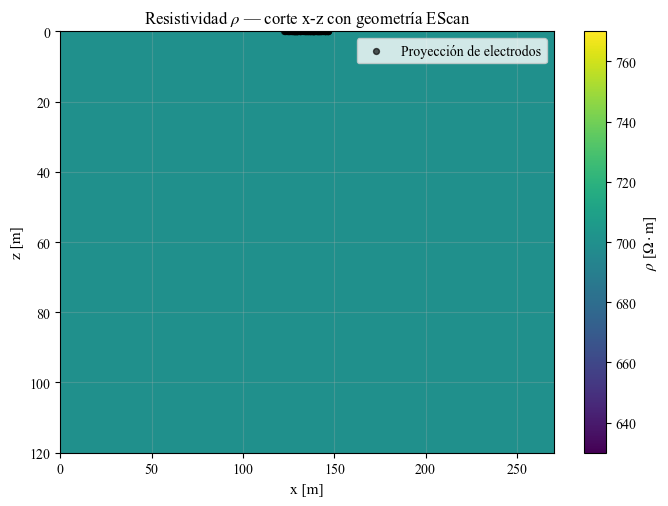

Figura guardada: C:\Users\tempc\Documents\figuras_bloque_6_escan_aleatorio\bloque6_escan_geometria_xy.png
Figura guardada: C:\Users\tempc\Documents\figuras_bloque_6_escan_aleatorio\bloque6_escan_geometria_xy.pdf


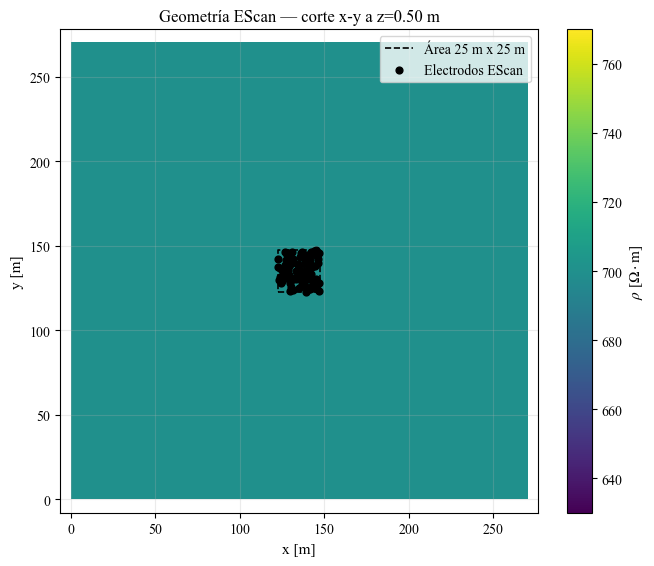

In [16]:
#%% ------------------------------------------------------------
# BLOQUE 6 — Geometría EScan aleatoria de electrodos
# ------------------------------------------------------------
# ============================================================
# Parámetros de la geometría
# ============================================================

geometry_type = "escan_aleatorio"

scan_size_x = 25.0
scan_size_y = 25.0

n_elec = 96
z_elec = 0.0

RANDOM_SEED_GEOM = 2026
MAX_ATTEMPTS = 200000

# Si True, evita que dos electrodos caigan en la misma celda numérica
ENFORCE_UNIQUE_CELLS = True

# Distancia mínima opcional entre electrodos en coordenadas físicas [m]
# Usa 0.0 para no imponer separación física adicional.
MIN_ELEC_DISTANCE = 0.0

# Centro del cuadrado dentro del dominio
x_center = 0.5 * Lx
y_center = 0.5 * Ly

x_min = x_center - 0.5 * scan_size_x
x_max = x_center + 0.5 * scan_size_x

y_min = y_center - 0.5 * scan_size_y
y_max = y_center + 0.5 * scan_size_y

# ============================================================
# Validación geométrica
# ============================================================

if x_min < 0.0 or x_max > Lx or y_min < 0.0 or y_max > Ly:
    raise ValueError(
        f"La geometría EScan no cabe en el dominio.\n"
        f"x_min={x_min:.2f}, x_max={x_max:.2f}, Lx={Lx:.2f}\n"
        f"y_min={y_min:.2f}, y_max={y_max:.2f}, Ly={Ly:.2f}"
    )

# ============================================================
# Construcción aleatoria reproducible
# ============================================================

rng = np.random.default_rng(RANDOM_SEED_GEOM)

x_list = []
y_list = []
p_set = set()

attempts = 0

while len(x_list) < n_elec and attempts < MAX_ATTEMPTS:

    attempts += 1

    x_candidate = rng.uniform(x_min, x_max)
    y_candidate = rng.uniform(y_min, y_max)
    p_candidate = xyz_to_p(x_candidate, y_candidate, z_elec)

    # Evitar celdas repetidas
    if ENFORCE_UNIQUE_CELLS and p_candidate in p_set:
        continue

    # Separación física mínima opcional
    if MIN_ELEC_DISTANCE > 0.0 and len(x_list) > 0:
        dist = np.sqrt(
            (np.asarray(x_list) - x_candidate)**2 +
            (np.asarray(y_list) - y_candidate)**2
        )

        if np.min(dist) < MIN_ELEC_DISTANCE:
            continue

    x_list.append(x_candidate)
    y_list.append(y_candidate)
    p_set.add(p_candidate)

if len(x_list) < n_elec:
    raise RuntimeError(
        f"No fue posible generar {n_elec} electrodos válidos "
        f"después de {MAX_ATTEMPTS} intentos. "
        "Reduce MIN_ELEC_DISTANCE o revisa hx/hy."
    )

x_elec = np.asarray(x_list, dtype=float)
y_elec = np.asarray(y_list, dtype=float)
z_elec_vec = np.full(n_elec, z_elec, dtype=float)

# Ordenar por y y luego x solo para que el recorrido sea reproducible
order = np.lexsort((x_elec, y_elec))
x_elec = x_elec[order]
y_elec = y_elec[order]
z_elec_vec = z_elec_vec[order]

electrode_xyz = list(zip(x_elec, y_elec, z_elec_vec))
electrode_p = [xyz_to_p(x, y, z) for (x, y, z) in electrode_xyz]

# Alias para compatibilidad
x_line = x_elec
y_line = y_elec
z_line = z_elec_vec

electrode_grid_shape = None
a_elec = np.nan

# ============================================================
# Validación de duplicados
# ============================================================

unique_p = np.unique(electrode_p)

if len(unique_p) < len(electrode_p):
    print("ADVERTENCIA:")
    print(
        f"{len(electrode_p) - len(unique_p)} electrodos caen en celdas repetidas."
    )

# ============================================================
# Información útil
# ============================================================

print("Geometría de electrodos: EScan aleatorio")
print("----------------------------------------")
print(f"Área de adquisición: {scan_size_x:.2f} m x {scan_size_y:.2f} m")
print(f"Número total de electrodos: {n_elec}")
print(f"Semilla aleatoria: {RANDOM_SEED_GEOM}")
print(f"x mínimo: {x_elec.min():.3f} m")
print(f"x máximo: {x_elec.max():.3f} m")
print(f"y mínimo: {y_elec.min():.3f} m")
print(f"y máximo: {y_elec.max():.3f} m")
print(f"Electrodos únicos en la malla numérica: {len(unique_p)} / {n_elec}")

# ============================================================
# Configuración de estilo y exportación de figuras
# ============================================================

fig_dir_b6 = "figuras_bloque_6_escan_aleatorio"
os.makedirs(fig_dir_b6, exist_ok=True)

SAVE_FIGS_B6 = True
SAVE_PDF_B6 = True
fig_dpi_b6 = 300

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10

def savefig_b6(fig, filename_base):
    if not SAVE_FIGS_B6:
        return

    png_path = os.path.join(fig_dir_b6, filename_base + ".png")
    fig.savefig(png_path, dpi=fig_dpi_b6, bbox_inches="tight", facecolor="white")
    print(f"Figura guardada: {os.path.abspath(png_path)}")

    if SAVE_PDF_B6:
        pdf_path = os.path.join(fig_dir_b6, filename_base + ".pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        print(f"Figura guardada: {os.path.abspath(pdf_path)}")

# ============================================================
# Visualización 1: corte x-z con proyección de electrodos
# ============================================================

fig, ax = plt.subplots(figsize=(7.0, 5.2))

im = ax.imshow(
    rho_xz,
    extent=extent_xz,
    origin="upper",
    aspect="auto",
    cmap="viridis"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\rho$ [$\Omega\cdot$m]")

ax.scatter(
    x_elec,
    np.zeros_like(x_elec),
    s=18,
    c="k",
    alpha=0.65,
    label="Proyección de electrodos"
)

ax.set_title(r"Resistividad $\rho$ — corte x-z con geometría EScan")
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.legend()
plt.tight_layout()

savefig_b6(fig, "bloque6_escan_proyeccion_xz")
plt.show()

# ============================================================
# Visualización 2: corte x-y a profundidad fija
# ============================================================

z_slice = 1.0
k_slice = int(np.argmin(np.abs(z_c - z_slice)))

rho_xy = rho[:, :, k_slice].T
extent_xy = [0.0, Lx, 0.0, Ly]

fig, ax = plt.subplots(figsize=(6.8, 5.8))

im = ax.imshow(
    rho_xy,
    extent=extent_xy,
    origin="lower",
    aspect="equal",
    cmap="viridis"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\rho$ [$\Omega\cdot$m]")

# Cuadro de adquisición
ax.plot(
    [x_min, x_max, x_max, x_min, x_min],
    [y_min, y_min, y_max, y_max, y_min],
    "k--",
    linewidth=1.2,
    label="Área 25 m x 25 m"
)

ax.scatter(
    x_elec,
    y_elec,
    s=24,
    c="k",
    label="Electrodos EScan"
)

ax.set_title(rf"Geometría EScan — corte x-y a z={z_c[k_slice]:.2f} m")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.axis("equal")
ax.legend()
plt.tight_layout()

savefig_b6(fig, "bloque6_escan_geometria_xy")
plt.show()



In [ ]:
# ------------------------------------------------------------
# BLOQUE 7 — Forward modeling completo para survey Polo–Polo
# ------------------------------------------------------------
# B/N remotos finitos + solver robusto + rhoa analítica y rhoa numérica
#
# DEFINICIONES
#  - Se usa un dipolo de corriente A-B con B remoto finito.
#  - Se mide ΔV = phi(M) - phi(N) con N remoto finito.
#  - Se calcula el factor geométrico exacto A-B / M-N.
#
# Corrección opcional mediante factor geométrico numérico:
#   - rho_a_num = K_num * ΔV / I
#   - K_num = rho_ref * I / ΔV_ref
#
# ============================================================
# Parámetros del survey y opciones principales
# ============================================================

survey_name = "polo_polo_practico_B_N_remotos_v9"

# Corriente inyectada [A]
I_survey = 1.0

# Pares de medición
# "unique_unordered": usa A-M sin repetir M-A. Más eficiente.
# "ordered"          : usa A->M y M->A.
PAIR_MODE = "unique_unordered"

# Submuestreo de mediciones
USE_RANDOM_SUBSAMPLING = True
MEASUREMENT_KEEP_FRACTION = 1.0
RANDOM_SEED = 1234

# Electrodos remotos
# B y N se ubican sobre el eje x, a REMOTE_FACTOR*rAMmax del centro del arreglo.
REMOTE_FACTOR = 3.5
REMOTE_MARGIN = 5.0   # margen al borde del dominio [m]

# Solver
# "auto": intenta LU; si falla, usa CG.
# "lu"  : fuerza LU.
# "cg"  : usa CG directamente. Recomendado si la LU tarda mucho o falla.
B7_SOLVER = "auto"
B7_CG_RTOL = 1e-8
B7_CG_MAXITER = 5000
CHUNK_SIZE = 16

# Corrección física por factor geométrico numérico
# Recomendado para validar modelos homogéneos y reducir el sesgo de frontera.
COMPUTE_NUMERICAL_GEOM_FACTOR = True

# Resistividad de referencia para rho_a_num
# Si existe rho_hom, se usa ese valor. Si no, se usa 700 ohm.m.
rho_ref_num = float(globals().get("rho_hom", 700.0))

# Gráficos
SAVE_FIGS_B7A = True
SAVE_PDF_B7A = True
SAVE_PNG_B7A = True
fig_dpi_b7A = 300
fig_dir_b7A = "figuras_bloque_7A_forward_polo_polo_v9"
os.makedirs(fig_dir_b7A, exist_ok=True)


# ============================================================
# Verificaciones de variables previas
# ============================================================

required_vars = [
    "electrode_p", "electrode_xyz",
    "x_c", "y_c", "z_c",
    "nx", "ny", "nz", "N",
    "Lx", "Ly",
    "A_gauge",
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        "Faltan variables requeridas para ejecutar el Bloque 7: "
        + ", ".join(missing_vars)
        + ". Reejecuta los bloques de malla, electrodos y ensamble del operador."
    )

USE_GAUGE = bool(globals().get("USE_GAUGE", False))
if USE_GAUGE and "ref_p" not in globals():
    raise NameError("USE_GAUGE=True, pero no existe ref_p.")

n_elec = len(electrode_p)

x_elec = np.array([xyz[0] for xyz in electrode_xyz], dtype=float)
y_elec = np.array([xyz[1] for xyz in electrode_xyz], dtype=float)
z_elec_array = np.array([xyz[2] for xyz in electrode_xyz], dtype=float)

coord_by_p = {
    int(p): np.array(xyz, dtype=float)
    for p, xyz in zip(electrode_p, electrode_xyz)
}

if "a_elec" not in globals():
    dx_unique = np.unique(np.round(np.diff(np.unique(x_elec)), 10))
    dy_unique = np.unique(np.round(np.diff(np.unique(y_elec)), 10))
    _spacing_values = np.r_[dx_unique, dy_unique]
    _spacing_values = _spacing_values[np.isfinite(_spacing_values) & (_spacing_values > 0)]
    if len(_spacing_values) == 0:
        a_elec = np.nan
    else:
        a_elec = float(np.nanmedian(_spacing_values))
    print("a_elec no existía; se estimó desde la geometría:", a_elec)

print("\nDiagnóstico inicial Bloque 7")
print("----------------------------")
print("A_gauge shape:", A_gauge.shape)
print("N esperado:", N)
print("A_gauge nnz:", A_gauge.nnz)
print("A_gauge dtype:", A_gauge.dtype)
print("USE_GAUGE:", USE_GAUGE)
print("rho_ref_num:", rho_ref_num, "ohm.m")

if A_gauge.shape != (N, N):
    raise ValueError(
        f"A_gauge tiene forma {A_gauge.shape}, pero N={N}. "
        "Reejecuta los bloques de malla/modelo/operador antes del Bloque 7."
    )

if not np.all(np.isfinite(A_gauge.data)):
    raise ValueError("A_gauge contiene NaN o Inf en sus datos.")


# ============================================================
# Funciones auxiliares de geometría
# ============================================================

def planar_distance_from_xy(x1, y1, x2, y2, min_dist=1e-12):
    r = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    if r < min_dist:
        return np.nan
    return float(r)


def planar_distance(p1: int, p2: int, min_dist: float = 1e-12) -> float:
    x1, y1, _ = coord_by_p[int(p1)]
    x2, y2, _ = coord_by_p[int(p2)]
    return planar_distance_from_xy(x1, y1, x2, y2, min_dist=min_dist)


def safe_inverse_distance(r):
    if not np.isfinite(r) or r <= 0:
        return np.nan
    return 1.0 / r


def geometric_denominator_ABMN(xA, yA, xB, yB, xM, yM, xN_, yN_):
    """
    Denominador geométrico para arreglo A-B / M-N:

        ΔV/I = rho/(2π) * (1/rAM - 1/rBM - 1/rAN + 1/rBN)

    Entonces:

        rho_a = 2π * ΔV/I / denom
              = 2π * G * ΔV/I, con G = 1/denom
    """

    r_AM = np.sqrt((xA - xM)**2 + (yA - yM)**2)
    r_BM = np.sqrt((xB - xM)**2 + (yB - yM)**2)
    r_AN = np.sqrt((xA - xN_)**2 + (yA - yN_)**2)
    r_BN = np.sqrt((xB - xN_)**2 + (yB - yN_)**2)

    vals = [r_AM, r_BM, r_AN, r_BN]
    if any((not np.isfinite(v)) or (v <= 0.0) for v in vals):
        return np.nan, vals

    denom = 1.0/r_AM - 1.0/r_BM - 1.0/r_AN + 1.0/r_BN
    return float(denom), vals


# ============================================================
# Cálculo de posiciones remotas B y N
# ============================================================

_dx_mat = x_elec[:, None] - x_elec[None, :]
_dy_mat = y_elec[:, None] - y_elec[None, :]
_dist_mat = np.sqrt(_dx_mat**2 + _dy_mat**2)
np.fill_diagonal(_dist_mat, np.nan)
r_AM_max_survey = float(np.nanmax(_dist_mat))

x_arr_center = 0.5 * (np.nanmin(x_elec) + np.nanmax(x_elec))
y_arr_center = 0.5 * (np.nanmin(y_elec) + np.nanmax(y_elec))

x_B_ideal = x_arr_center + REMOTE_FACTOR * r_AM_max_survey
x_N_ideal = x_arr_center - REMOTE_FACTOR * r_AM_max_survey
y_BN_ideal = y_arr_center

x_B_remote = float(np.clip(x_B_ideal, REMOTE_MARGIN, Lx - REMOTE_MARGIN))
x_N_remote = float(np.clip(x_N_ideal, REMOTE_MARGIN, Lx - REMOTE_MARGIN))
y_BN_remote = float(np.clip(y_BN_ideal, REMOTE_MARGIN, Ly - REMOTE_MARGIN))

if abs(x_B_remote - x_B_ideal) > 1e-6:
    print(
        f"AVISO: B fue recortado por el dominio: "
        f"x_B={x_B_remote:.2f} m, ideal={x_B_ideal:.2f} m"
    )

if abs(x_N_remote - x_N_ideal) > 1e-6:
    print(
        f"AVISO: N fue recortado por el dominio: "
        f"x_N={x_N_remote:.2f} m, ideal={x_N_ideal:.2f} m"
    )

_ix_B = int(np.argmin(np.abs(x_c - x_B_remote)))
_iy_B = int(np.argmin(np.abs(y_c - y_BN_remote)))
_iz_B = 0

_ix_N = int(np.argmin(np.abs(x_c - x_N_remote)))
_iy_N = int(np.argmin(np.abs(y_c - y_BN_remote)))
_iz_N = 0

p_B_remote = int(_ix_B + nx * _iy_B + nx * ny * _iz_B)
p_N_remote = int(_ix_N + nx * _iy_N + nx * ny * _iz_N)

x_B_real = float(x_c[_ix_B])
y_B_real = float(y_c[_iy_B])
x_N_real = float(x_c[_ix_N])
y_N_real = float(y_c[_iy_N])

active_set = set(int(p) for p in electrode_p)
if p_B_remote in active_set:
    print("ADVERTENCIA: B remoto coincide con un electrodo activo. Aumenta el dominio o reduce REMOTE_FACTOR.")
if p_N_remote in active_set:
    print("ADVERTENCIA: N remoto coincide con un electrodo activo. Aumenta el dominio o reduce REMOTE_FACTOR.")
if p_B_remote == p_N_remote:
    raise ValueError("B remoto y N remoto caen en la misma celda. Aumenta el dominio o reduce REMOTE_FACTOR.")

dist_B_to_array = float(np.sqrt((x_elec - x_B_real)**2 + (y_elec - y_B_real)**2).min())
dist_N_to_array = float(np.sqrt((x_elec - x_N_real)**2 + (y_elec - y_N_real)**2).min())

print("\nPolo-polo práctico — electrodos remotos")
print("----------------------------------------")
print(f"r_AM_max del survey         = {r_AM_max_survey:.3f} m")
print(f"REMOTE_FACTOR               = {REMOTE_FACTOR}")
print(f"B: x={x_B_real:.2f} m, y={y_B_real:.2f} m, p={p_B_remote}")
print(f"N: x={x_N_real:.2f} m, y={y_N_real:.2f} m, p={p_N_remote}")
print(f"dist(B, arreglo)_min        = {dist_B_to_array:.1f} m "
      f"({dist_B_to_array/r_AM_max_survey:.2f} × r_AM_max)")
print(f"dist(N, arreglo)_min        = {dist_N_to_array:.1f} m "
      f"({dist_N_to_array/r_AM_max_survey:.2f} × r_AM_max)")


# ============================================================
# Construcción del survey polo-polo práctico
# ============================================================

measurements_pp_all = []
pair_id = 0

if PAIR_MODE == "unique_unordered":

    for iA in range(n_elec):
        for iM in range(iA + 1, n_elec):

            A_p = int(electrode_p[iA])
            M_p = int(electrode_p[iM])

            xA, yA, _ = coord_by_p[A_p]
            xM, yM, _ = coord_by_p[M_p]

            r_AM = planar_distance(A_p, M_p)
            if not np.isfinite(r_AM):
                continue

            x_center = 0.5 * (xA + xM)
            y_center = 0.5 * (yA + yM)

            measurements_pp_all.append(
                (
                    A_p,
                    p_B_remote,
                    M_p,
                    p_N_remote,
                    pair_id,
                    r_AM,
                    x_center,
                    y_center,
                    "AM_unique",
                )
            )
            pair_id += 1

elif PAIR_MODE == "ordered":

    for iA in range(n_elec):
        for iM in range(n_elec):

            if iA == iM:
                continue

            A_p = int(electrode_p[iA])
            M_p = int(electrode_p[iM])

            xA, yA, _ = coord_by_p[A_p]
            xM, yM, _ = coord_by_p[M_p]

            r_AM = planar_distance(A_p, M_p)
            if not np.isfinite(r_AM):
                continue

            x_center = 0.5 * (xA + xM)
            y_center = 0.5 * (yA + yM)

            measurements_pp_all.append(
                (
                    A_p,
                    p_B_remote,
                    M_p,
                    p_N_remote,
                    pair_id,
                    r_AM,
                    x_center,
                    y_center,
                    "AM_ordered",
                )
            )
            pair_id += 1

else:
    raise ValueError("PAIR_MODE debe ser 'unique_unordered' u 'ordered'.")

print("\nSurvey polo-polo práctico")
print("-------------------------")
print(f"Nombre del survey: {survey_name}")
print(f"Modo de pares: {PAIR_MODE}")
print(f"Número de electrodos activos: {n_elec}")
print(f"Número total de mediciones antes del filtro: {len(measurements_pp_all)}")

if USE_RANDOM_SUBSAMPLING:
    if not (0.0 < MEASUREMENT_KEEP_FRACTION <= 1.0):
        raise ValueError("MEASUREMENT_KEEP_FRACTION debe estar en (0, 1].")

    rng = np.random.default_rng(RANDOM_SEED)
    n_total = len(measurements_pp_all)
    n_keep = int(np.ceil(MEASUREMENT_KEEP_FRACTION * n_total))

    keep_idx = rng.choice(n_total, size=n_keep, replace=False)
    keep_idx = np.sort(keep_idx)

    measurements_pp = [measurements_pp_all[i] for i in keep_idx]
else:
    measurements_pp = measurements_pp_all

print(f"Fracción de mediciones conservada: {MEASUREMENT_KEEP_FRACTION:.3f}")
print(f"Número final de mediciones usadas: {len(measurements_pp)}")

measurements_w: List[Tuple[int, int, int, int, int, float, float]] = [
    (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center)
    for (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, pair_label)
    in measurements_pp
]

measurements = [
    (A_p, B_p, M_p, N_p)
    for (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, pair_label)
    in measurements_pp
]

measurements_pp_combined = measurements_pp
measurements_simple_combined = measurements

print("measurements simple listo para bloques posteriores. N =", len(measurements))


# ============================================================
# Solver robusto
# ============================================================

def prepare_matrix_for_superlu(A_in):
    """
    Limpia y convierte A para SuperLU.
    Evita varios casos que producen:
        SystemError: gstrf was called with invalid arguments
    """

    A_csc = sp.csc_matrix(A_in, dtype=np.float64, copy=True)

    A_csc.sum_duplicates()
    A_csc.eliminate_zeros()
    A_csc.sort_indices()

    if A_csc.shape[0] != A_csc.shape[1]:
        raise ValueError(f"La matriz no es cuadrada: {A_csc.shape}")

    if not np.all(np.isfinite(A_csc.data)):
        raise ValueError("La matriz contiene NaN o Inf.")

    if A_csc.nnz == 0:
        raise ValueError("La matriz no tiene entradas no nulas.")

    if A_csc.indices.size > 0:
        if A_csc.indices.min() < 0 or A_csc.indices.max() >= A_csc.shape[0]:
            raise ValueError("La matriz tiene índices fuera de rango.")

    int32_max = np.iinfo(np.int32).max
    if A_csc.shape[0] > int32_max or A_csc.nnz > int32_max:
        raise MemoryError("La matriz excede el límite int32 de SuperLU.")

    A_csc = sp.csc_matrix(
        (
            A_csc.data.astype(np.float64, copy=False),
            A_csc.indices.astype(np.int32, copy=False),
            A_csc.indptr.astype(np.int32, copy=False),
        ),
        shape=A_csc.shape
    )

    return A_csc


def prepare_matrix_for_cg(A_in):
    """
    Prepara A en CSR para CG.
    """
    A_csr = sp.csr_matrix(A_in, dtype=np.float64, copy=True)
    A_csr.sum_duplicates()
    A_csr.eliminate_zeros()
    A_csr.sort_indices()

    if A_csr.shape[0] != A_csr.shape[1]:
        raise ValueError(f"La matriz no es cuadrada: {A_csr.shape}")

    if not np.all(np.isfinite(A_csr.data)):
        raise ValueError("La matriz contiene NaN o Inf.")

    return A_csr


def build_solver_B7(A_in, solver_mode="auto", label="A"):
    """
    Retorna:
        solve_fun(Bmat)
        solver_used
    """

    A_lu_local = None
    A_csr_local = None
    M_prec_local = None
    solver_used = None

    if solver_mode in ["auto", "lu"]:

        try:
            print(f"\n[{label}] Intentando factorización LU con SuperLU...")
            A_csc = prepare_matrix_for_superlu(A_in)

            print(f"[{label}] shape={A_csc.shape}, nnz={A_csc.nnz}")
            print(f"[{label}] dtype data={A_csc.data.dtype}, "
                  f"indices={A_csc.indices.dtype}, indptr={A_csc.indptr.dtype}")

            A_lu_local = spla.splu(
                A_csc,
                permc_spec="COLAMD",
                diag_pivot_thresh=1.0
            )

            solver_used = "lu"
            print(f"[{label}] LU terminada correctamente.")

        except Exception as err:
            print(f"\n[{label}] ADVERTENCIA: falló la factorización LU.")
            print("Tipo de error:", type(err).__name__)
            print("Mensaje:", err)

            if solver_mode == "lu":
                raise

            print(f"[{label}] Se usará CG iterativo como alternativa.\n")
            A_lu_local = None
            gc.collect()

    if solver_used is None:

        print(f"\n[{label}] Preparando solver CG...")
        A_csr_local = prepare_matrix_for_cg(A_in)

        diag_A = A_csr_local.diagonal()
        if np.any(~np.isfinite(diag_A)):
            raise ValueError(f"[{label}] La diagonal contiene NaN o Inf.")
        if np.any(np.abs(diag_A) < 1e-30):
            raise ValueError(f"[{label}] La diagonal tiene valores casi cero.")

        M_inv = 1.0 / diag_A

        M_prec_local = spla.LinearOperator(
            shape=A_csr_local.shape,
            matvec=lambda x: M_inv * x
        )

        solver_used = "cg"

        print(f"[{label}] CG listo. shape={A_csr_local.shape}, nnz={A_csr_local.nnz}")

    def solve_fun(Bmat):
        """
        Resuelve A X = Bmat.
        """

        Bmat = np.asarray(Bmat, dtype=float)

        if Bmat.ndim == 1:
            Bmat_2d = Bmat[:, None]
            squeeze_output = True
        else:
            Bmat_2d = Bmat
            squeeze_output = False

        if solver_used == "lu":
            X = A_lu_local.solve(Bmat_2d)

        elif solver_used == "cg":
            X = np.zeros_like(Bmat_2d, dtype=float)

            for col in range(Bmat_2d.shape[1]):

                rhs = Bmat_2d[:, col]

                if np.linalg.norm(rhs) == 0.0:
                    X[:, col] = 0.0
                    continue

                try:
                    x, info = spla.cg(
                        A_csr_local,
                        rhs,
                        M=M_prec_local,
                        rtol=B7_CG_RTOL,
                        atol=0.0,
                        maxiter=B7_CG_MAXITER
                    )
                except TypeError:
                    # Compatibilidad con SciPy antiguo
                    x, info = spla.cg(
                        A_csr_local,
                        rhs,
                        M=M_prec_local,
                        tol=B7_CG_RTOL,
                        maxiter=B7_CG_MAXITER
                    )

                if info != 0:
                    raise RuntimeError(
                        f"[{label}] CG no convergió en columna {col}. info={info}. "
                        "Prueba aumentar B7_CG_MAXITER, relajar B7_CG_RTOL o usar un dominio/padding más estable."
                    )

                X[:, col] = x

        else:
            raise ValueError(f"solver_used desconocido: {solver_used}")

        if squeeze_output:
            return X[:, 0]
        return X

    return solve_fun, solver_used



# ============================================================
# Solver global cacheado para reutilizar A_gauge en Bloques 7, 8 y 9
# ============================================================
# Este solver se construye una sola vez para la matriz A_gauge del modelo actual.
# Los bloques posteriores pueden resolver nuevos RHS mediante solve_Agauge_cached(...)
# sin volver a factorizar la matriz.

print("\nConstruyendo solver global reutilizable para A_gauge...")
B7_SOLVE_FUN, SOLVER_USED_B7 = build_solver_B7(
    A_gauge,
    solver_mode=B7_SOLVER,
    label="A_gauge_global"
)

B7_SOLVER_CACHE = {
    "solve_fun": B7_SOLVE_FUN,
    "solver_used": SOLVER_USED_B7,
    "shape": A_gauge.shape,
    "nnz": A_gauge.nnz,
    "id_A_gauge": id(A_gauge),
}


def solve_Agauge_cached(Bmat):
    """
    Resuelve A_gauge X = Bmat usando el solver/factorización construido
    en el Bloque 7. Esta función evita refactorizar A_gauge en los
    Bloques 8 y 9.
    """

    if "B7_SOLVE_FUN" not in globals():
        raise RuntimeError(
            "No existe B7_SOLVE_FUN. Ejecuta primero el Bloque 7 completo."
        )

    if (
        A_gauge.shape != B7_SOLVER_CACHE["shape"]
        or A_gauge.nnz != B7_SOLVER_CACHE["nnz"]
        or id(A_gauge) != B7_SOLVER_CACHE["id_A_gauge"]
    ):
        raise RuntimeError(
            "A_gauge cambió después de construir el solver cacheado. "
            "Reejecuta el Bloque 7 para reconstruir solve_Agauge_cached."
        )

    return B7_SOLVE_FUN(Bmat)


print("Solver global reutilizable listo.")
print("Solver usado en A_gauge_global:", SOLVER_USED_B7)

# ============================================================
# Forward solver para una matriz dada
# ============================================================

unique_A = np.array(
    sorted(set(A_p for (A_p, _, _, _, _, _, _, _, _) in measurements_pp)),
    dtype=int
)

obs_p_set = set(M_p for (_, _, M_p, _, _, _, _, _, _) in measurements_pp)
obs_p_set.add(int(p_N_remote))

obs_p = np.array(sorted(obs_p_set), dtype=int)
obs_pos = {int(p): i for i, p in enumerate(obs_p)}

print("\nPrecomputación optimizada de potenciales")
print("----------------------------------------")
print(f"Número de fuentes A únicas: {len(unique_A)}")
print(f"Número de mediciones: {len(measurements_pp)}")
print(f"Nodos de observación necesarios: {len(obs_p)}")
print(f"Tamaño del sistema: N = {N}")


def compute_phi_obs_by_source(
    A_matrix,
    solver_mode="auto",
    label="target",
    solve_fun_external=None,
    solver_used_external=None,
):
    """
    Resuelve el forward para todas las fuentes A únicas.
    Guarda únicamente phi en los nodos de observación obs_p.

    RHS para cada fuente:
        +I en A
        -I en B remoto

    Si solve_fun_external se entrega, reutiliza un solver ya construido.
    Esto evita refactorizar A_gauge cuando se resuelve el modelo actual.
    """

    if solve_fun_external is None:
        solve_fun, solver_used = build_solver_B7(
            A_matrix,
            solver_mode=solver_mode,
            label=label
        )
    else:
        solve_fun = solve_fun_external
        solver_used = solver_used_external if solver_used_external is not None else "cached"

    phi_obs_by_A = {}

    t_start = time.perf_counter()

    nA = len(unique_A)

    for start in range(0, nA, CHUNK_SIZE):

        end = min(start + CHUNK_SIZE, nA)
        A_chunk = unique_A[start:end]

        Bmat = np.zeros((N, len(A_chunk)), dtype=float)

        for col, A_p in enumerate(A_chunk):
            Bmat[int(A_p), col] += I_survey
            Bmat[int(p_B_remote), col] -= I_survey

        if USE_GAUGE:
            Bmat[int(ref_p), :] = 0.0

        Phi_chunk = solve_fun(Bmat)
        Phi_obs_chunk = Phi_chunk[obs_p, :]

        for col, A_p in enumerate(A_chunk):
            phi_obs_by_A[int(A_p)] = Phi_obs_chunk[:, col].copy()

        print(f"[{label}] Fuentes {start + 1}-{end} de {nA} completadas.")

    t_end = time.perf_counter()

    print(f"[{label}] Tiempo total: {t_end - t_start:.2f} s")
    print(f"[{label}] Solver usado: {solver_used}")

    return phi_obs_by_A, solver_used


# ============================================================
# Forward del modelo actual
# ============================================================

phi_obs_by_elec, SOLVER_USED_B7 = compute_phi_obs_by_source(
    A_gauge,
    solver_mode=B7_SOLVER,
    label="modelo_actual",
    solve_fun_external=solve_Agauge_cached,
    solver_used_external=SOLVER_USED_B7,
)


# ============================================================
# Cálculo de ΔV y rho_a analítica
# ============================================================

n_data = len(measurements_pp)

data_dV = np.zeros(n_data, dtype=float)
rho_a = np.zeros(n_data, dtype=float)
rho_a_analytic = np.zeros(n_data, dtype=float)

pair_id_array = np.zeros(n_data, dtype=int)
r_am_array = np.zeros(n_data, dtype=float)
x_cent = np.zeros(n_data, dtype=float)
y_cent = np.zeros(n_data, dtype=float)
geom_G = np.zeros(n_data, dtype=float)
geom_denom = np.zeros(n_data, dtype=float)

pair_labels = []

for m, (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, pair_label) in enumerate(measurements_pp):

    A_p = int(A_p)
    M_p = int(M_p)

    phi_obs = phi_obs_by_elec[A_p]

    phi_M = phi_obs[obs_pos[M_p]]
    phi_N = phi_obs[obs_pos[int(p_N_remote)]]
    dV = phi_M - phi_N

    xA_g, yA_g, _ = coord_by_p[A_p]
    xM_g, yM_g, _ = coord_by_p[M_p]

    denom, _rvals = geometric_denominator_ABMN(
        xA_g, yA_g,
        x_B_real, y_B_real,
        xM_g, yM_g,
        x_N_real, y_N_real
    )

    if (not np.isfinite(denom)) or abs(denom) < 1e-30:
        G = np.nan
        rho_val = np.nan
    else:
        G = 1.0 / denom
        rho_val = 2.0 * np.pi * G * (dV / I_survey)

    data_dV[m] = dV
    rho_a[m] = rho_val
    rho_a_analytic[m] = rho_val

    geom_G[m] = G
    geom_denom[m] = denom

    pair_id_array[m] = pair_id
    r_am_array[m] = r_AM
    x_cent[m] = x_center
    y_cent[m] = y_center
    pair_labels.append(pair_label)


# ============================================================
# Factor geométrico numérico opcional
# ============================================================

rho_a_num = None
K_num = None
data_dV_ref = None
USED_NUMERICAL_GEOM_FACTOR = False

def apply_gauge_like_current(A_raw):
    """
    Aplica la misma condición de gauge usada por el sistema actual.
    Solo modifica si USE_GAUGE=True.
    """
    if not USE_GAUGE:
        return A_raw

    A_mod = sp.lil_matrix(A_raw)
    rp = int(ref_p)

    A_mod[rp, :] = 0.0
    A_mod[:, rp] = 0.0
    A_mod[rp, rp] = 1.0

    return A_mod.tocsr()


def current_sigma_is_reference():
    """
    Detecta si el modelo actual parece homogéneo con sigma=1/rho_ref_num.
    Esto permite usar data_dV como referencia sin resolver otra vez.
    """
    if "sigma" not in globals():
        return False

    sig_arr = np.asarray(globals()["sigma"], dtype=float)
    sig_ref = 1.0 / rho_ref_num

    if sig_arr.size == 0:
        return False
    if not np.all(np.isfinite(sig_arr)):
        return False

    rel = np.nanmax(np.abs(sig_arr - sig_ref)) / max(abs(sig_ref), 1e-30)
    return bool(rel < 1e-8)


if COMPUTE_NUMERICAL_GEOM_FACTOR:

    print("\nFactor geométrico numérico")
    print("--------------------------")

    try:

        if current_sigma_is_reference():

            print("El modelo actual parece homogéneo de referencia.")
            print("Se usa ΔV del modelo actual como ΔV_ref.")
            data_dV_ref = data_dV.copy()

        else:

            if "assemble_A_FV" not in globals():
                raise NameError(
                    "No existe assemble_A_FV. No puedo construir A_ref_gauge. "
                    "Se continuará solo con rho_a analítica."
                )

            print("Construyendo modelo homogéneo de referencia...")
            sigma_ref_value = 1.0 / rho_ref_num
            sigma_ref = np.full((nx, ny, nz), sigma_ref_value, dtype=float)

            A_ref_raw = assemble_A_FV(sigma_ref)
            A_ref_gauge = apply_gauge_like_current(A_ref_raw)

            print("Resolviendo forward de referencia homogénea...")
            phi_obs_ref_by_elec, SOLVER_USED_REF = compute_phi_obs_by_source(
                A_ref_gauge,
                solver_mode=B7_SOLVER,
                label="referencia_homogenea"
            )

            data_dV_ref = np.zeros(n_data, dtype=float)

            for m, (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, pair_label) in enumerate(measurements_pp):

                A_p = int(A_p)
                M_p = int(M_p)

                phi_obs_ref = phi_obs_ref_by_elec[A_p]

                phi_M_ref = phi_obs_ref[obs_pos[M_p]]
                phi_N_ref = phi_obs_ref[obs_pos[int(p_N_remote)]]

                data_dV_ref[m] = phi_M_ref - phi_N_ref

        K_num = np.full(n_data, np.nan, dtype=float)
        valid_ref = np.isfinite(data_dV_ref) & (np.abs(data_dV_ref) > 1e-30)
        K_num[valid_ref] = rho_ref_num * I_survey / data_dV_ref[valid_ref]

        rho_a_num = K_num * (data_dV / I_survey)

        USED_NUMERICAL_GEOM_FACTOR = True

        print("Factor geométrico numérico calculado.")
        print("rho_a_num mínimo:", np.nanmin(rho_a_num))
        print("rho_a_num máximo:", np.nanmax(rho_a_num))
        print("rho_a_num mediana:", np.nanmedian(rho_a_num))

    except Exception as err:

        print("\nADVERTENCIA: no se pudo calcular rho_a_num.")
        print("Tipo de error:", type(err).__name__)
        print("Mensaje:", err)
        print("Se continuará usando rho_a analítica.")

        rho_a_num = None
        K_num = None
        data_dV_ref = None
        USED_NUMERICAL_GEOM_FACTOR = False


# Variable final recomendada para graficar e interpretar
if USED_NUMERICAL_GEOM_FACTOR and rho_a_num is not None:
    rho_a_final = rho_a_num
    rho_a_final_label = r"$\rho_a^{num}$ [$\Omega\cdot$m]"
    rho_a_final_name = "rho_a_num"
else:
    rho_a_final = rho_a
    rho_a_final_label = r"$\rho_a$ [$\Omega\cdot$m]"
    rho_a_final_name = "rho_a_analytic"


# Compatibilidad con gráficos/bloques previos
s_level = np.ones(n_data, dtype=int)

print("\nDatos calculados")
print("----------------")
print("ΔV mínimo:", np.nanmin(data_dV))
print("ΔV máximo:", np.nanmax(data_dV))
print("rho_a analítica mínimo:", np.nanmin(rho_a_analytic))
print("rho_a analítica máximo:", np.nanmax(rho_a_analytic))
print("rho_a analítica mediana:", np.nanmedian(rho_a_analytic))

if rho_a_num is not None:
    print("rho_a numérica mínimo:", np.nanmin(rho_a_num))
    print("rho_a numérica máximo:", np.nanmax(rho_a_num))
    print("rho_a numérica mediana:", np.nanmedian(rho_a_num))

print("rho_a_final usada para interpretación:", rho_a_final_name)

# Objeto final del survey
survey_pp_combined = {
    "name": survey_name,
    "pair_mode": PAIR_MODE,
    "keep_fraction": MEASUREMENT_KEEP_FRACTION,
    "measurements_full": measurements_pp,
    "measurements_simple": measurements,
    "data_dV": data_dV,
    "rho_a": rho_a,
    "rho_a_analytic": rho_a_analytic,
    "rho_a_num": rho_a_num,
    "rho_a_final": rho_a_final,
    "rho_a_final_name": rho_a_final_name,
    "r_am": r_am_array,
    "x_center": x_cent,
    "y_center": y_cent,
    "pair_id": pair_id_array,
    "geom_G": geom_G,
    "geom_denom": geom_denom,
    "K_num": K_num,
    "data_dV_ref": data_dV_ref,
    "p_B_remote": p_B_remote,
    "p_N_remote": p_N_remote,
    "B_remote_xyz": np.array([x_B_real, y_B_real, 0.0]),
    "N_remote_xyz": np.array([x_N_real, y_N_real, 0.0]),
    "solver_used": SOLVER_USED_B7,
    "used_numerical_geom_factor": USED_NUMERICAL_GEOM_FACTOR,
}

print("Objeto survey_pp_combined creado.")


# ============================================================
# Estilo y guardado de figuras
# ============================================================

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["figure.titlesize"] = 13


def savefig_b7A(fig, filename_base):
    if not SAVE_FIGS_B7A:
        return

    if SAVE_PNG_B7A:
        png_path = os.path.join(fig_dir_b7A, filename_base + ".png")
        fig.savefig(
            png_path,
            dpi=fig_dpi_b7A,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(png_path)}")

    if SAVE_PDF_B7A:
        pdf_path = os.path.join(fig_dir_b7A, filename_base + ".pdf")
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(pdf_path)}")


# ============================================================
# Gráfico 1: ΔV por índice de medición
# ============================================================

fig, ax = plt.subplots(figsize=(7.6, 4.0))

ax.plot(data_dV, "o-", ms=3, lw=1.0)

ax.set_title(r"Diferencia de potencial $\Delta V$ — polo-polo práctico")
ax.set_xlabel("Índice de medición")
ax.set_ylabel(r"$\Delta V$ [V]")
ax.grid(True, alpha=0.25)

plt.tight_layout()
savefig_b7A(fig, "bloque7A_deltaV_por_indice_polo_polo_v9")
plt.show()


# ============================================================
# Gráfico 2: rho_a vs distancia A-M
# ============================================================

valid = np.isfinite(r_am_array) & np.isfinite(rho_a_final) & (r_am_array > 0)

r_valid = r_am_array[valid]
rho_valid = rho_a_final[valid]

idx_sort = np.argsort(r_valid)
r_sorted = r_valid[idx_sort]
rho_sorted = rho_valid[idx_sort]

N_R_BINS = 30

if len(r_sorted) > 0:

    r_bins = np.linspace(np.nanmin(r_sorted), np.nanmax(r_sorted), N_R_BINS + 1)
    r_bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

    rho_med = np.full(N_R_BINS, np.nan)
    rho_p25 = np.full(N_R_BINS, np.nan)
    rho_p75 = np.full(N_R_BINS, np.nan)
    n_bin = np.zeros(N_R_BINS, dtype=int)

    for i in range(N_R_BINS):

        if i < N_R_BINS - 1:
            mask_bin = (r_sorted >= r_bins[i]) & (r_sorted < r_bins[i + 1])
        else:
            mask_bin = (r_sorted >= r_bins[i]) & (r_sorted <= r_bins[i + 1])

        n_bin[i] = np.sum(mask_bin)

        if n_bin[i] > 0:
            rho_med[i] = np.nanmedian(rho_sorted[mask_bin])
            rho_p25[i] = np.nanpercentile(rho_sorted[mask_bin], 25)
            rho_p75[i] = np.nanpercentile(rho_sorted[mask_bin], 75)

    mask_nonempty = n_bin > 0

    fig, ax = plt.subplots(figsize=(8.2, 4.8))

    ax.scatter(
        r_sorted,
        rho_sorted,
        s=12,
        alpha=0.20,
        label="Mediciones individuales"
    )

    ax.plot(
        r_bin_centers[mask_nonempty],
        rho_med[mask_nonempty],
        "o-",
        lw=2.0,
        ms=5,
        label="Mediana por intervalo de distancia"
    )

    ax.fill_between(
        r_bin_centers[mask_nonempty],
        rho_p25[mask_nonempty],
        rho_p75[mask_nonempty],
        alpha=0.25,
        label="Rango intercuartílico 25–75 %"
    )



    ax.set_title(
        rf"Resistividad aparente {rho_a_final_name} — polo-polo práctico"
    )
    ax.set_xlabel(r"Distancia A-M, $r_{AM}$ [m]")
    ax.set_ylabel(rho_a_final_label)
    ax.grid(True, alpha=0.25)
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    savefig_b7A(fig, f"bloque7A_{rho_a_final_name}_vs_distancia_AM_v9")
    plt.show()

else:
    print("No hay datos válidos para graficar rho_a vs r_AM.")


# ============================================================
# Gráfico 3: comparación rho_a analítica vs numérica
# ============================================================

if rho_a_num is not None:

    valid_cmp = (
        np.isfinite(r_am_array)
        & np.isfinite(rho_a_analytic)
        & np.isfinite(rho_a_num)
        & (r_am_array > 0)
    )

    fig, ax = plt.subplots(figsize=(8.2, 4.8))

    ax.scatter(
        r_am_array[valid_cmp],
        rho_a_analytic[valid_cmp],
        s=12,
        alpha=0.25,
        label=r"$\rho_a$ analítica ABMN"
    )

    ax.scatter(
        r_am_array[valid_cmp],
        rho_a_num[valid_cmp],
        s=12,
        alpha=0.25,
        label=r"$\rho_a^{num}$ corregida"
    )



    ax.set_title("Comparación de resistividad aparente")
    ax.set_xlabel(r"Distancia A-M, $r_{AM}$ [m]")
    ax.set_ylabel(r"$\rho_a$ [$\Omega\cdot$m]")
    ax.grid(True, alpha=0.25)
    ax.legend(framealpha=0.9)

    plt.tight_layout()
    savefig_b7A(fig, "bloque7A_comparacion_rhoa_analitica_numerica_v9")
    plt.show()


# ============================================================
# Gráfico 4: mapa espacial de centros de medición
# ============================================================

valid_map = (
    np.isfinite(x_cent)
    & np.isfinite(y_cent)
    & np.isfinite(rho_a_final)
)

fig, ax = plt.subplots(figsize=(7.0, 6.0))

sc = ax.scatter(
    x_cent[valid_map],
    y_cent[valid_map],
    c=rho_a_final[valid_map],
    s=24,
    alpha=0.85,
    cmap="turbo"
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(rho_a_final_label)

ax.scatter(
    x_elec,
    y_elec,
    s=14,
    c="k",
    alpha=0.35,
    label="Electrodos activos"
)

ax.scatter(
    [x_B_real],
    [y_B_real],
    s=90,
    marker="v",
    c="tab:red",
    edgecolors="k",
    label="B remoto"
)

ax.scatter(
    [x_N_real],
    [y_N_real],
    s=90,
    marker="^",
    c="tab:green",
    edgecolors="k",
    label="N remoto"
)

ax.set_title(f"Distribución espacial de {rho_a_final_name}")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.axis("equal")
ax.legend(framealpha=0.9)

plt.tight_layout()
savefig_b7A(fig, f"bloque7A_mapa_espacial_{rho_a_final_name}_v9")
plt.show()


# ============================================================
# Gráfico 5: geometría del survey con B y N remotos
# ============================================================

if len(measurements_pp) > 0:

    example_idx = len(measurements_pp) // 2
    A_p_ex, B_p_ex, M_p_ex, N_p_ex, pair_id_ex, r_AM_ex, x_center_ex, y_center_ex, pair_label_ex = measurements_pp[example_idx]

    A_p_ex = int(A_p_ex)
    M_p_ex = int(M_p_ex)

    xA_ex, yA_ex, _ = coord_by_p[A_p_ex]
    xM_ex, yM_ex, _ = coord_by_p[M_p_ex]

    fig, ax = plt.subplots(figsize=(10.0, 6.0))

    ax.scatter(
        x_elec,
        y_elec,
        c="k",
        s=18,
        alpha=0.45,
        label="Electrodos del arreglo",
        zorder=3
    )

    ax.scatter(
        [xA_ex],
        [yA_ex],
        s=140,
        c="tab:blue",
        edgecolors="k",
        linewidths=0.8,
        label="A: fuente +I",
        zorder=5
    )

    ax.scatter(
        [xM_ex],
        [yM_ex],
        s=140,
        c="tab:orange",
        edgecolors="k",
        linewidths=0.8,
        label="M: potencial",
        zorder=5
    )

    ax.scatter(
        [x_B_real],
        [y_B_real],
        s=180,
        c="tab:red",
        edgecolors="k",
        linewidths=0.8,
        marker="v",
        label=f"B remoto: -I  (x={x_B_real:.1f} m)",
        zorder=5
    )

    ax.scatter(
        [x_N_real],
        [y_N_real],
        s=180,
        c="tab:green",
        edgecolors="k",
        linewidths=0.8,
        marker="^",
        label=f"N remoto: ref. V  (x={x_N_real:.1f} m)",
        zorder=5
    )

    ax.plot(
        [xA_ex, xM_ex],
        [yA_ex, yM_ex],
        "--",
        lw=1.4,
        c="k",
        label=r"Distancia $r_{AM}$",
        zorder=2
    )

    ax.plot(
        [x_N_real, x_B_real],
        [y_N_real, y_B_real],
        ":",
        lw=1.2,
        c="gray",
        label="Eje B-N remoto",
        zorder=2
    )

    for xp, yp, lbl in [
        (xA_ex, yA_ex, " A"),
        (xM_ex, yM_ex, " M"),
        (x_B_real, y_B_real, " B"),
        (x_N_real, y_N_real, " N"),
    ]:
        ax.text(xp, yp, lbl, fontsize=11, fontweight="bold", va="bottom", zorder=6)

    ax.set_title(
        "Geometría del survey — polo-polo práctico con B y N remotos\n"
        + f"par={pair_id_ex}, rAM≈{r_AM_ex:.2f} m"
    )
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.axis("equal")
    ax.legend(framealpha=0.9, loc="upper right")

    plt.tight_layout()
    savefig_b7A(fig, "bloque7A_ejemplo_medicion_polo_polo_v9")
    plt.show()


# ============================================================
# Resumen final
# ============================================================

print("\nResumen Bloque 7 v9")
print("-------------------")
print("Solver usado modelo actual:", SOLVER_USED_B7)
print("Usó factor geométrico numérico:", USED_NUMERICAL_GEOM_FACTOR)
print("Variable recomendada para interpretación: rho_a_final")
print("Nombre de rho_a_final:", rho_a_final_name)
print("Objeto principal: survey_pp_combined")
print("Carpeta de figuras:", os.path.abspath(fig_dir_b7A))

In [18]:
#%% ------------------------------------------------------------
# BLOQUE 7B — Exportación mínima para inversión TRE 3D
# ------------------------------------------------------------

# ============================================================
# Configuración mínima
# ============================================================

EXPORT_TRUE_MODEL = False   # True si quieres guardar sigma/rho para validar inversión sintética

relative_error = 0.03       # error relativo sugerido, 3 %
voltage_floor = 1e-6        # piso de error en voltaje [V]

geometry_tag = globals().get("geometry_type", "geometria")
model_tag_export = globals().get("model_tag", globals().get("MODEL_TYPE", "modelo"))

export_dir = os.path.join(
    "inversion_input_TRE3D",
    f"{geometry_tag}_{model_tag_export}"
)

os.makedirs(export_dir, exist_ok=True)

# ============================================================
# Validación de variables requeridas
# ============================================================

required_b7b = [
    "measurements_pp",
    "data_dV",
    "electrode_xyz",
    "electrode_p",
    "x_elec",
    "y_elec",
    "z_elec_vec",
    "n_elec",
    "I_survey",
    "dx",
    "dy",
    "dz",
    "x_edges",
    "y_edges",
    "z_edges",
    "x_c",
    "y_c",
    "z_c",
    "nx",
    "ny",
    "nz",
    "N",
    "Lx",
    "Ly",
    "Lz"
]

for name in required_b7b:
    if name not in globals():
        raise NameError(f"Falta la variable '{name}'. Ejecuta los bloques previos.")

# ============================================================
# Seleccionar resistividad aparente a exportar
# ============================================================

if "rho_a_num" in globals():
    rho_app_export = np.asarray(rho_a_num, dtype=float)
    rho_app_type = "rho_a_num"

elif "rho_a" in globals():
    rho_app_export = np.asarray(rho_a, dtype=float)
    rho_app_type = "rho_a"

elif "rho_app" in globals():
    rho_app_export = np.asarray(rho_app, dtype=float)
    rho_app_type = "rho_app"

else:
    raise NameError("No se encontró rho_a_num, rho_a ni rho_app.")

data_dV_export = np.asarray(data_dV, dtype=float)

n_data = len(measurements_pp)

if len(data_dV_export) != n_data:
    raise ValueError("data_dV no tiene la misma longitud que measurements_pp.")

if len(rho_app_export) != n_data:
    raise ValueError("rho_a/rho_app no tiene la misma longitud que measurements_pp.")

# ============================================================
# Función para leer mediciones del Bloque 7
# ============================================================

def parse_measurement_item(item):
    """
    Soporta dos formatos:

    Formato estándar:
        (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, label)

    Formato reducido:
        (A_p, M_p, tag, r_AM, x_center, y_center, label)

    En el formato reducido se asume polo-polo ideal:
        B_p = -1
        N_p = -1
    """
    if len(item) == 9:
        A_p, B_p, M_p, N_p, tag, r_AM, x_center, y_center, label = item

    elif len(item) == 7:
        A_p, M_p, tag, r_AM, x_center, y_center, label = item
        B_p = -1
        N_p = -1

    else:
        raise ValueError(
            f"Formato inesperado en measurements_pp. "
            f"Se esperaban 9 o 7 campos, pero se recibieron {len(item)}."
        )

    return (
        int(A_p),
        int(B_p),
        int(M_p),
        int(N_p),
        int(tag),
        float(r_AM),
        float(x_center),
        float(y_center),
        str(label)
    )

# ============================================================
# Mapa entre índice interno p y electrodo
# ============================================================

electrode_p_array = np.asarray(electrode_p, dtype=int)

if len(np.unique(electrode_p_array)) != len(electrode_p_array):
    raise ValueError(
        "Existen electrodos distintos que caen en la misma celda numérica. "
        "Esto hace ambigua la exportación para inversión. "
        "Refina la malla superficial o ajusta la posición de los electrodos."
    )

# IDs de electrodos 0-based, consistentes con Python
p_to_eid = {
    int(p): int(i)
    for i, p in enumerate(electrode_p_array)
}


# ── Helpers de identificación de electrodos ──────────────────────────────────

def is_inf(p):
    """
    Devuelve True si p representa un electrodo en el infinito lógico.
    En polo-polo ideal el centinela era -1.
    En polo-polo práctico B y N son índices reales, no infinito.
    """
    return int(p) < 0

def electrode_id_from_p(p):
    # Caso 1: centinela de infinito (polo-polo ideal legado)
    if is_inf(p):
        return -1

    # Caso 2: electrodo B remoto (polo-polo práctico)
    # p_B_remote y p_N_remote son electrodos auxiliares definidos en
    # Bloque 7 v9 que no forman parte del arreglo de medición activo.
    # Se les asigna un ID negativo especial para mantener trazabilidad
    # en los archivos exportados sin romper la indexación de electrodos.
    _p_B = int(globals().get("p_B_remote", -999))
    _p_N = int(globals().get("p_N_remote", -999))

    if int(p) == _p_B:
        return -2   # ID especial: electrodo B remoto
    if int(p) == _p_N:
        return -3   # ID especial: electrodo N remoto

    # Caso 3: electrodo del arreglo activo
    if p not in p_to_eid:
        raise KeyError(
            f"El índice de celda p={p} no aparece en electrode_p. "
            "Revisa que measurements_pp y electrode_p provengan de la misma geometría."
        )
    return p_to_eid[p]


def coord_from_eid(eid):
    """
    Devuelve coordenadas de electrodo.
    Si eid < 0, devuelve NaN porque representa infinito.
    """
    eid = int(eid)

    if eid < 0:
        return np.nan, np.nan, np.nan

    return (
        float(x_elec[eid]),
        float(y_elec[eid]),
        float(z_elec_vec[eid])
    )

# ============================================================
# Construcción de tabla mínima de datos para inversión
# ============================================================

survey_rows = []

for m, item in enumerate(measurements_pp):

    A_p, B_p, M_p, N_p, tag, r_AM, x_center, y_center, label = parse_measurement_item(item)

    A_eid = electrode_id_from_p(A_p)
    B_eid = electrode_id_from_p(B_p)
    M_eid = electrode_id_from_p(M_p)
    N_eid = electrode_id_from_p(N_p)

    Ax, Ay, Az = coord_from_eid(A_eid)
    Bx, By, Bz = coord_from_eid(B_eid)
    Mx, My, Mz = coord_from_eid(M_eid)
    Nx_, Ny_, Nz_ = coord_from_eid(N_eid)

    dV = float(data_dV_export[m])
    rhoa = float(rho_app_export[m])

    if np.isfinite(dV) and abs(dV) > 1e-30:
        K_eff = rhoa * float(I_survey) / dV
    else:
        K_eff = np.nan

    std_V = relative_error * abs(dV) + voltage_floor

    survey_rows.append({
        "data_id": m,

        # IDs de electrodos 0-based
        # Convención de IDs especiales en B_elec y N_elec:
        #   -1 : infinito lógico (polo-polo ideal legado)
        #   -2 : electrodo B remoto (polo-polo práctico, p = p_B_remote)
        #   -3 : electrodo N remoto (polo-polo práctico, p = p_N_remote)
        "A_elec": A_eid,
        "B_elec": B_eid,
        "M_elec": M_eid,
        "N_elec": N_eid,

        # Índices internos de celda usados por el operador
        "A_p": A_p,
        "B_p": B_p,
        "M_p": M_p,
        "N_p": N_p,

        # Coordenadas de electrodos
        "A_x": Ax,
        "A_y": Ay,
        "A_z": Az,

        "B_x": Bx,
        "B_y": By,
        "B_z": Bz,

        "M_x": Mx,
        "M_y": My,
        "M_z": Mz,

        "N_x": Nx_,
        "N_y": Ny_,
        "N_z": Nz_,

        # Datos para inversión
        "current_A": float(I_survey),
        "dobs_V": dV,
        "std_V": std_V,

        # Información auxiliar
        "rho_app_ohm_m": rhoa,
        "K_eff_m": K_eff,
        "r_AM_m": float(r_AM),
        "x_center_m": float(x_center),
        "y_center_m": float(y_center),

        "tag": tag,
        "label": label
    })

survey_df = pd.DataFrame(survey_rows)

# ============================================================
# Validaciones finales
# ============================================================

if np.any(survey_df["A_elec"].to_numpy() == survey_df["M_elec"].to_numpy()):
    raise ValueError("Existen mediciones con A_elec == M_elec.")

if np.any(~np.isfinite(survey_df["dobs_V"].to_numpy())):
    raise ValueError("Existen valores no finitos en dobs_V.")

if np.any(~np.isfinite(survey_df["std_V"].to_numpy())):
    raise ValueError("Existen valores no finitos en std_V.")

if np.any(survey_df["std_V"].to_numpy() <= 0):
    raise ValueError("Existen desviaciones estándar menores o iguales a cero.")

n_data_expected = n_elec * (n_elec - 1) // 2

print("Validación de exportación")
print("-------------------------")
print(f"n_elec = {n_elec}")
print(f"n_data = {n_data}")
print(f"n_data esperado para pares únicos = {n_data_expected}")
print(f"Resistividad aparente exportada: {rho_app_type}")

PAIR_MODE_EXPORT = globals().get("PAIR_MODE", "no_definido")

if PAIR_MODE_EXPORT == "unique_unordered" and n_data != n_data_expected:
    print("ADVERTENCIA:")
    print(
        f"PAIR_MODE='unique_unordered', pero n_data={n_data} "
        f"y se esperaban {n_data_expected}."
    )

# ============================================================
# 1) Exportar datos de inversión
# ============================================================

survey_path = os.path.join(export_dir, "survey_data_for_inversion.csv")
survey_df.to_csv(survey_path, index=False)

# ============================================================
# 2) Exportar electrodos
# ============================================================

electrodes_df = pd.DataFrame({
    "electrode_id": np.arange(n_elec, dtype=int),
    "x": np.asarray(x_elec, dtype=float),
    "y": np.asarray(y_elec, dtype=float),
    "z": np.asarray(z_elec_vec, dtype=float),
    "cell_p": np.asarray(electrode_p, dtype=int)
})

electrodes_path = os.path.join(export_dir, "electrodes.csv")
electrodes_df.to_csv(electrodes_path, index=False)

# ============================================================
# 3) Exportar malla tensorial con padding
# ============================================================

mesh_path = os.path.join(export_dir, "mesh_tensor_padding.npz")

np.savez_compressed(
    mesh_path,

    nx=np.array([nx], dtype=np.int64),
    ny=np.array([ny], dtype=np.int64),
    nz=np.array([nz], dtype=np.int64),
    N=np.array([N], dtype=np.int64),

    Lx=np.array([Lx], dtype=np.float64),
    Ly=np.array([Ly], dtype=np.float64),
    Lz=np.array([Lz], dtype=np.float64),

    dx=np.asarray(dx, dtype=np.float64),
    dy=np.asarray(dy, dtype=np.float64),
    dz=np.asarray(dz, dtype=np.float64),

    x_edges=np.asarray(x_edges, dtype=np.float64),
    y_edges=np.asarray(y_edges, dtype=np.float64),
    z_edges=np.asarray(z_edges, dtype=np.float64),

    x_c=np.asarray(x_c, dtype=np.float64),
    y_c=np.asarray(y_c, dtype=np.float64),
    z_c=np.asarray(z_c, dtype=np.float64)
)

# ============================================================
# 4) Exportar modelo verdadero opcional
# ============================================================

if EXPORT_TRUE_MODEL:

    if "sigma" not in globals() or "rho" not in globals():
        raise NameError("Para exportar el modelo verdadero deben existir sigma y rho.")

    true_model_path = os.path.join(export_dir, "true_model_sigma_rho.npz")

    np.savez_compressed(
        true_model_path,
        sigma=np.asarray(sigma, dtype=np.float32),
        rho=np.asarray(rho, dtype=np.float32)
    )

# ============================================================
# 5) Metadatos mínimos
# ============================================================

metadata = {
    "geometry_type": str(geometry_tag),
    "model_type": str(globals().get("MODEL_TYPE", "no_definido")),
    "model_tag": str(model_tag_export),
    "boundary_mode": str(globals().get("BOUNDARY_MODE", "no_definido")),

    "survey_type": "pole-pole practical",
    "electrode_id_base": "0-based",
    "B_remote_p": int(globals().get("p_B_remote", -1)),
    "N_remote_p": int(globals().get("p_N_remote", -1)),
    "B_remote_x_m": float(globals().get("x_B_real", float("nan"))),
    "N_remote_x_m": float(globals().get("x_N_real", float("nan"))),
    "B_remote_y_m": float(globals().get("y_B_real", float("nan"))),
    "remote_factor": float(globals().get("REMOTE_FACTOR", float("nan"))),

    "n_electrodes": int(n_elec),
    "n_data": int(n_data),
    "n_data_expected_unique_unordered": int(n_data_expected),

    "current_A": float(I_survey),
    "rho_app_type": str(rho_app_type),

    "relative_error": float(relative_error),
    "voltage_floor": float(voltage_floor),

    "mesh_type": "tensorial_padding",
    "nx": int(nx),
    "ny": int(ny),
    "nz": int(nz),
    "N": int(N),
    "Lx_m": float(Lx),
    "Ly_m": float(Ly),
    "Lz_m": float(Lz),

    "files": {
        "survey_data": os.path.basename(survey_path),
        "electrodes": os.path.basename(electrodes_path),
        "mesh": os.path.basename(mesh_path),
        "true_model": "true_model_sigma_rho.npz" if EXPORT_TRUE_MODEL else None
    }
}

metadata_path = os.path.join(export_dir, "metadata.json")

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

# ============================================================
# Resumen final
# ============================================================

print("")
print("Exportación mínima para inversión TRE 3D completada")
print("--------------------------------------------------")
print(f"Directorio: {os.path.abspath(export_dir)}")
print(f"Datos de inversión: {os.path.basename(survey_path)}")
print(f"Electrodos: {os.path.basename(electrodes_path)}")
print(f"Malla: {os.path.basename(mesh_path)}")
print(f"Metadatos: {os.path.basename(metadata_path)}")

if EXPORT_TRUE_MODEL:
    print(f"Modelo verdadero: {os.path.basename(true_model_path)}")

print("")
print(f"ρa min/max = {np.nanmin(rho_app_export):.3f} / {np.nanmax(rho_app_export):.3f} Ω·m")
print(f"ΔV min/max = {np.nanmin(data_dV_export):.6e} / {np.nanmax(data_dV_export):.6e} V")
print(f"std_V min/max = {survey_df['std_V'].min():.6e} / {survey_df['std_V'].max():.6e} V")

Validación de exportación
-------------------------
n_elec = 96
n_data = 4560
n_data esperado para pares únicos = 4560
Resistividad aparente exportada: rho_a_num

Exportación mínima para inversión TRE 3D completada
--------------------------------------------------
Directorio: C:\Users\tempc\Documents\inversion_input_TRE3D\escan_aleatorio_modelo_homogeneo_700ohmm
Datos de inversión: survey_data_for_inversion.csv
Electrodos: electrodes.csv
Malla: mesh_tensor_padding.npz
Metadatos: metadata.json

ρa min/max = 700.000 / 700.000 Ω·m
ΔV min/max = 2.631655e+00 / 9.778562e+01 V
std_V min/max = 7.895064e-02 / 2.933570e+00 V


In [ ]:
# ------------------------------------------------------------
# BLOQUE 8  — Diagnóstico local de potencial, E y J
# ------------------------------------------------------------
# Objetivo:
#   - Diagnosticar el campo de potencial, E y J sin que la visualización quede dominada por los electrodos remotos o por el padding.
# ------------------------------------------------------------

# ============================================================
# Configuración
# ============================================================

RUN_B8 = True

# Modo recomendado:
#   "survey_measurement" -> toma una medición real de measurements_pp.
#   "manual_AB"          -> define A y B manualmente desde electrode_p.
#   "polo_polo_ideal"    -> solo diagnóstico antiguo; no recomendado si usas Bloque 7 con B remoto.
B8_SOURCE_MODE = "survey_measurement"

# Índice de medición usado si B8_SOURCE_MODE = "survey_measurement".
# Usa None para seleccionar automáticamente una medición cercana a r_AM mediano.
B8_MEASUREMENT_INDEX = None

# Índices de electrodos activos si B8_SOURCE_MODE = "manual_AB" o "polo_polo_ideal".
B8_A_ELEC = 0
B8_B_ELEC = None          # None usa p_B_remote si existe; si no, n_elec-1
B8_M_ELEC = None          # None usa el último electrodo activo

# Visualización:
#   "core"       -> muestra solo la zona fina de interés.
#   "full"       -> muestra todo el dominio.
#   "custom"     -> usa B8_XLIM y B8_ZLIM.
B8_VIEW_MODE = "core"

B8_XLIM = None            # ejemplo: (100.0, 170.0)
B8_ZLIM = None            # ejemplo: (0.0, 50.0)

# Si el core no existe, se usará todo el dominio.
B8_SHOW_ACTIVE_ELECTRODES = True
B8_SHOW_REMOTE_ELECTRODES = True

# Quiver
B8_QUIVER_NX = 35
B8_QUIVER_NZ = 25
B8_QUIVER_MIN_REL = 1e-2       # no mostrar flechas con |J| < 1 % del máximo visible
B8_QUIVER_MIN_PERCENTILE = 75  # además, filtra flechas debajo del percentil visible
B8_QUIVER_SCALE = 35

# Color
B8_USE_LOG_JMAG = True
B8_JMAG_LOG_FLOOR_REL = 1e-6

# Solver
#   "auto" usa build_solver_B7 si existe; si no, usa CG local.
#   "cg"   fuerza CG local.
B8_SOLVER = "auto"
B8_CG_RTOL = 1e-8
B8_CG_MAXITER = 5000

# Exportación
fig_dir_b8 = "figuras_bloque_8_diagnostico_local_E_J"
os.makedirs(fig_dir_b8, exist_ok=True)

SAVE_FIGS_B8 = True
SAVE_PDF_B8 = True
SAVE_PNG_B8 = True
fig_dpi_b8 = 300

# ============================================================
# Estilo gráfico
# ============================================================

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["figure.titlesize"] = 13


# ============================================================
# Funciones auxiliares
# ============================================================

def savefig_b8(fig, filename_base):
    if not SAVE_FIGS_B8:
        return

    if SAVE_PNG_B8:
        png_path = os.path.join(fig_dir_b8, filename_base + ".png")
        fig.savefig(
            png_path,
            dpi=fig_dpi_b8,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(png_path)}")

    if SAVE_PDF_B8:
        pdf_path = os.path.join(fig_dir_b8, filename_base + ".pdf")
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(pdf_path)}")


def is_remote_or_infinity_b8(p):
    return int(p) < 0


def p_to_ijk_b8(p):
    p = int(p)
    iz = p // (nx * ny)
    rem = p - iz * nx * ny
    iy = rem // nx
    ix = rem - iy * nx
    return ix, iy, iz


def p_to_xyz_b8(p):
    ix, iy, iz = p_to_ijk_b8(p)
    return float(x_c[ix]), float(y_c[iy]), float(z_c[iz])


def sigma_to_grid_b8(sig):
    sig = np.asarray(sig, dtype=float)

    if sig.shape == (nx, ny, nz):
        return sig

    if sig.size == N:
        return sig.reshape((nx, ny, nz), order="F")

    raise ValueError(
        f"No puedo convertir sigma a grilla ({nx}, {ny}, {nz}). "
        f"Forma actual: {sig.shape}, tamaño: {sig.size}"
    )


def parse_measurement_b8(item):
    """
    Soporta mediciones del Bloque 7 moderno:
      (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, label)

    y mediciones antiguas:
      (A_p, M_p, tag, r_AM, x_center, y_center, label)
    """

    if len(item) == 9:
        A_p, B_p, M_p, N_p, tag, r_AM, x_center, y_center, label = item

    elif len(item) == 7:
        A_p, M_p, tag, r_AM, x_center, y_center, label = item
        B_p = globals().get("B_INF", -1)
        N_p = globals().get("N_INF", -1)

    else:
        raise ValueError(f"Formato inesperado de measurement: {len(item)} campos.")

    return (
        int(A_p),
        int(B_p),
        int(M_p),
        int(N_p),
        tag,
        float(r_AM),
        float(x_center),
        float(y_center),
        str(label),
    )


def select_measurement_b8():
    """
    Selecciona una medición representativa del survey.
    Por defecto, escoge una medición cercana a la distancia A-M mediana.
    """

    if "measurements_pp" not in globals():
        raise NameError(
            "No existe measurements_pp. Ejecuta el Bloque 7 antes del Bloque 8."
        )

    parsed = [parse_measurement_b8(m) for m in measurements_pp]

    if B8_MEASUREMENT_INDEX is not None:
        idx = int(B8_MEASUREMENT_INDEX)
        idx = max(0, min(idx, len(parsed) - 1))
        return idx, parsed[idx]

    rams = np.array([m[5] for m in parsed], dtype=float)
    rmed = np.nanmedian(rams)

    idx = int(np.nanargmin(np.abs(rams - rmed)))
    return idx, parsed[idx]


def solve_phi_b8(rhs):
    """
    Resuelve A_gauge phi = rhs.

    Prioridad:
      1. Reutilizar solve_Agauge_cached creado en el Bloque 7.
      2. Si no existe, construir un solver con build_solver_B7.
      3. Como último recurso, usar CG local.
    """

    rhs = np.asarray(rhs, dtype=float)

    if "solve_Agauge_cached" in globals():
        print("[Bloque 8] Reutilizando solver cacheado del Bloque 7.")
        return solve_Agauge_cached(rhs)

    if B8_SOLVER == "auto" and "build_solver_B7" in globals():
        print("[Bloque 8] No existe solve_Agauge_cached; construyendo solver con build_solver_B7...")
        solve_fun, solver_used = build_solver_B7(
            A_gauge,
            solver_mode=globals().get("B7_SOLVER", "auto"),
            label="B8"
        )
        phi = solve_fun(rhs)
        print(f"[Bloque 8] Solver usado: {solver_used}")
        return phi

    print("[Bloque 8] Usando CG local...")

    A_csr = sp.csr_matrix(A_gauge, dtype=float)
    A_csr.sum_duplicates()
    A_csr.eliminate_zeros()
    A_csr.sort_indices()

    diag_A = A_csr.diagonal()

    if np.any(~np.isfinite(diag_A)):
        raise ValueError("La diagonal de A_gauge contiene NaN o Inf.")

    if np.any(np.abs(diag_A) < 1e-30):
        raise ValueError("La diagonal de A_gauge contiene valores casi cero.")

    M_inv = 1.0 / diag_A
    M = spla.LinearOperator(A_csr.shape, matvec=lambda x: M_inv * x)

    try:
        phi, info = spla.cg(
            A_csr,
            rhs,
            M=M,
            rtol=B8_CG_RTOL,
            atol=0.0,
            maxiter=B8_CG_MAXITER
        )
    except TypeError:
        phi, info = spla.cg(
            A_csr,
            rhs,
            M=M,
            tol=B8_CG_RTOL,
            maxiter=B8_CG_MAXITER
        )

    if info != 0:
        raise RuntimeError(f"CG no convergió en Bloque 8. info={info}")

    return phi


def compute_EJ_b8(phi3d, sigma3d):
    """
    Calcula E=-grad(phi) y J=sigma E.
    Compatible con malla no uniforme.
    """

    dphidx, dphidy, dphidz = np.gradient(
        phi3d,
        x_c,
        y_c,
        z_c,
        edge_order=2
    )

    Ex = -dphidx
    Ey = -dphidy
    Ez = -dphidz

    Jx = sigma3d * Ex
    Jy = sigma3d * Ey
    Jz = sigma3d * Ez

    Emag = np.sqrt(Ex**2 + Ey**2 + Ez**2)
    Jmag = np.sqrt(Jx**2 + Jy**2 + Jz**2)

    return Ex, Ey, Ez, Emag, Jx, Jy, Jz, Jmag


def get_view_limits_b8():
    """
    Retorna límites de visualización:
      xlim = (xmin, xmax)
      zlim = (zmin, zmax), con zmin cercano a 0 y zmax profundidad.
    """

    if B8_VIEW_MODE == "custom":
        if B8_XLIM is None or B8_ZLIM is None:
            raise ValueError("B8_VIEW_MODE='custom' requiere B8_XLIM y B8_ZLIM.")
        return tuple(B8_XLIM), tuple(B8_ZLIM)

    if B8_VIEW_MODE == "core":

        if all(name in globals() for name in ["x_core_start", "x_core_end"]):
            xlim = (float(x_core_start), float(x_core_end))
        else:
            xlim = (float(x_edges[0]), float(x_edges[-1]))

        if "z_core_end" in globals():
            zlim = (0.0, float(z_core_end))
        else:
            zlim = (float(z_edges[0]), float(z_edges[-1]))

        return xlim, zlim

    if B8_VIEW_MODE == "full":
        return (float(x_edges[0]), float(x_edges[-1])), (float(z_edges[0]), float(z_edges[-1]))

    raise ValueError("B8_VIEW_MODE debe ser 'core', 'full' o 'custom'.")


def crop_indices_b8(xlim, zlim):
    ix0 = int(np.searchsorted(x_edges, xlim[0], side="left"))
    ix1 = int(np.searchsorted(x_edges, xlim[1], side="right")) - 1

    iz0 = int(np.searchsorted(z_edges, zlim[0], side="left"))
    iz1 = int(np.searchsorted(z_edges, zlim[1], side="right")) - 1

    ix0 = max(0, min(ix0, len(x_edges) - 2))
    ix1 = max(ix0 + 1, min(ix1, len(x_edges) - 1))

    iz0 = max(0, min(iz0, len(z_edges) - 2))
    iz1 = max(iz0 + 1, min(iz1, len(z_edges) - 1))

    return ix0, ix1, iz0, iz1


def add_electrode_marker_b8(ax, p, label, marker, color, xlim, zlim, size=95):
    """
    Agrega marcador si el electrodo/nodo cae dentro de la ventana.
    """
    if is_remote_or_infinity_b8(p):
        return False

    xp, yp, zp = p_to_xyz_b8(p)

    if not (xlim[0] <= xp <= xlim[1] and zlim[0] <= zp <= zlim[1]):
        return False

    ax.scatter(
        [xp],
        [zp],
        marker=marker,
        s=size,
        c=color,
        edgecolors="k",
        linewidths=0.8,
        label=label,
        zorder=8
    )

    ax.text(
        xp,
        zp,
        f" {label}",
        fontsize=10,
        fontweight="bold",
        va="bottom",
        zorder=9
    )

    return True


def format_depth_axes_b8(ax, xlim, zlim):
    """
    Formato tipo perfil de profundidad:
      - x arriba
      - z=0 arriba
      - profundidad positiva hacia abajo
    """
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(zlim[1], zlim[0])

    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.tick_params(
        axis="x",
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False
    )

    ax.set_xlabel("x [m]")
    ax.set_ylabel("Profundidad z [m]")
    ax.grid(True, alpha=0.20)


# ============================================================
# Ejecución
# ============================================================

if RUN_B8:

    required_b8 = [
        "A_gauge",
        "sigma",
        "electrode_p",
        "electrode_xyz",
        "x_c",
        "y_c",
        "z_c",
        "x_edges",
        "z_edges",
        "vec_to_grid",
        "I_survey",
        "nx",
        "ny",
        "nz",
        "N",
        "Ly"
    ]

    for name in required_b8:
        if name not in globals():
            raise NameError(f"Falta '{name}'. Ejecuta los bloques previos antes del Bloque 8.")

    sigma_grid_b8 = sigma_to_grid_b8(sigma)

    # ------------------------------------------------------------
    # Definir fuente A-B y marcadores M-N
    # ------------------------------------------------------------

    if B8_SOURCE_MODE == "survey_measurement":

        meas_idx, meas = select_measurement_b8()
        A_p, B_p, M_p, N_p, tag, r_AM, x_center, y_center, label = meas

        source_label_b8 = (
            f"Medición real del survey #{meas_idx}: "
            f"A={A_p}, B={B_p}, M={M_p}, N={N_p}, rAM={r_AM:.2f} m"
        )

    elif B8_SOURCE_MODE == "manual_AB":

        n_elec = len(electrode_p)

        A_p = int(electrode_p[int(B8_A_ELEC)])

        if B8_B_ELEC is None:
            if "p_B_remote" in globals():
                B_p = int(p_B_remote)
            else:
                B_p = int(electrode_p[n_elec - 1])
        else:
            B_p = int(electrode_p[int(B8_B_ELEC)])

        if B8_M_ELEC is None:
            M_p = int(electrode_p[n_elec - 1])
        else:
            M_p = int(electrode_p[int(B8_M_ELEC)])

        N_p = int(globals().get("p_N_remote", -1))

        source_label_b8 = f"Manual AB: A={A_p}, B={B_p}, M={M_p}, N={N_p}"

    elif B8_SOURCE_MODE == "polo_polo_ideal":

        n_elec = len(electrode_p)

        A_p = int(electrode_p[int(B8_A_ELEC)])
        B_p = -1

        if B8_M_ELEC is None:
            M_p = int(electrode_p[n_elec - 1])
        else:
            M_p = int(electrode_p[int(B8_M_ELEC)])

        N_p = -1

        source_label_b8 = (
            f"Polo-polo ideal diagnóstico: A={A_p}, retorno en frontera/infinito, M={M_p}"
        )

        print(
            "ADVERTENCIA: B8_SOURCE_MODE='polo_polo_ideal' no es el modo recomendado "
            "si el Bloque 7 usa B y N remotos finitos."
        )

    else:
        raise ValueError(
            "B8_SOURCE_MODE debe ser 'survey_measurement', 'manual_AB' o 'polo_polo_ideal'."
        )

    # ------------------------------------------------------------
    # RHS
    # ------------------------------------------------------------

    rhs_b8 = np.zeros(N, dtype=float)

    rhs_b8[int(A_p)] += I_survey

    if not is_remote_or_infinity_b8(B_p):
        rhs_b8[int(B_p)] -= I_survey
    else:
        print(
            "AVISO: B_p es infinito/frontera. La corriente cerrará en la frontera numérica. "
            "Para diagnóstico consistente con Bloque 7, usa B remoto finito."
        )

    if globals().get("USE_GAUGE", False):
        rhs_b8[int(ref_p)] = 0.0

    # ------------------------------------------------------------
    # Resolver potencial y calcular J
    # ------------------------------------------------------------

    print("")
    print("Bloque 8 v2 — diagnóstico local de E y J")
    print("----------------------------------------")
    print(source_label_b8)

    t0_b8 = time.perf_counter()

    phi_vec_b8 = solve_phi_b8(rhs_b8)
    phi_b8 = vec_to_grid(phi_vec_b8)

    Ex, Ey, Ez, Emag, Jx, Jy, Jz, Jmag = compute_EJ_b8(phi_b8, sigma_grid_b8)

    print(f"[Bloque 8] Solución y campos listos en {time.perf_counter() - t0_b8:.2f} s")

    # ------------------------------------------------------------
    # Corte x-z en y del centro del arreglo/medición
    # ------------------------------------------------------------

    if B8_SOURCE_MODE == "survey_measurement":
        # usar el y del centro de la medición si está disponible
        y_slice_target = float(y_center)
    else:
        y_slice_target = float(0.5 * Ly)

    iy_mid = int(np.argmin(np.abs(y_c - y_slice_target)))

    phi_xz = phi_b8[:, iy_mid, :].T
    Jx_xz = Jx[:, iy_mid, :].T
    Jz_xz = Jz[:, iy_mid, :].T
    Jmag_xz = Jmag[:, iy_mid, :].T

    xlim_b8, zlim_b8 = get_view_limits_b8()
    ix0, ix1, iz0, iz1 = crop_indices_b8(xlim_b8, zlim_b8)

    x_edges_plot = x_edges[ix0:ix1 + 1]
    z_edges_plot = z_edges[iz0:iz1 + 1]

    phi_plot = phi_xz[iz0:iz1, ix0:ix1]
    Jmag_plot = Jmag_xz[iz0:iz1, ix0:ix1]

    # ------------------------------------------------------------
    # Quiver recortado y filtrado
    # ------------------------------------------------------------

    nx_plot = max(1, ix1 - ix0)
    nz_plot = max(1, iz1 - iz0)

    skip_x = max(1, nx_plot // B8_QUIVER_NX)
    skip_z = max(1, nz_plot // B8_QUIVER_NZ)

    xq = x_c[ix0:ix1:skip_x]
    zq = z_c[iz0:iz1:skip_z]

    Xq, Zq = np.meshgrid(xq, zq, indexing="xy")

    Jx_q = Jx_xz[iz0:iz1:skip_z, ix0:ix1:skip_x]
    Jz_q = Jz_xz[iz0:iz1:skip_z, ix0:ix1:skip_x]

    Jq = np.sqrt(Jx_q**2 + Jz_q**2)

    if np.any(np.isfinite(Jq)):
        jq_max = max(float(np.nanmax(Jq)), 1e-30)
        jq_pct = float(np.nanpercentile(Jq[np.isfinite(Jq)], B8_QUIVER_MIN_PERCENTILE))
        jq_thr = max(B8_QUIVER_MIN_REL * jq_max, jq_pct, 1e-30)
    else:
        jq_thr = np.inf

    mask_q = np.isfinite(Jq) & (Jq >= jq_thr)

    Jx_qn = np.zeros_like(Jx_q)
    Jz_qn = np.zeros_like(Jz_q)

    Jx_qn[mask_q] = Jx_q[mask_q] / Jq[mask_q]
    Jz_qn[mask_q] = Jz_q[mask_q] / Jq[mask_q]

    # ------------------------------------------------------------
    # Figura
    # ------------------------------------------------------------

    fig, ax = plt.subplots(1, 2, figsize=(13.2, 5.4))

    # Potencial
    im0 = ax[0].pcolormesh(
        x_edges_plot,
        z_edges_plot,
        phi_plot,
        shading="auto",
        cmap="viridis"
    )

    try:
        ax[0].contour(
            x_c[ix0:ix1],
            z_c[iz0:iz1],
            phi_plot,
            levels=12,
            colors="k",
            linewidths=0.65,
            alpha=0.50
        )
    except Exception as err:
        print("AVISO: no se pudieron trazar contornos de phi:", err)

    format_depth_axes_b8(ax[0], (x_edges[ix0], x_edges[ix1]), (z_edges[iz0], z_edges[iz1]))

    ax[0].set_title(r"Potencial $\phi$ — corte x-z local")

    cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
    cbar0.set_label(r"$\phi$ [V]")

    # J
    if B8_USE_LOG_JMAG:
        jmax_plot = max(float(np.nanmax(Jmag_plot)), 1e-30)
        jmin_plot = max(jmax_plot * B8_JMAG_LOG_FLOOR_REL, 1e-30)
        norm_j = LogNorm(vmin=jmin_plot, vmax=jmax_plot)
        J_color = np.maximum(Jmag_plot, jmin_plot)
    else:
        norm_j = None
        J_color = Jmag_plot

    im1 = ax[1].pcolormesh(
        x_edges_plot,
        z_edges_plot,
        J_color,
        shading="auto",
        cmap="magma",
        norm=norm_j
    )

    if np.any(mask_q):
        ax[1].quiver(
            Xq[mask_q],
            Zq[mask_q],
            Jx_qn[mask_q],
            Jz_qn[mask_q],
            color="white",
            scale=B8_QUIVER_SCALE,
            width=0.0022,
            alpha=0.90
        )
    else:
        print("AVISO: no hay vectores J por encima del umbral de visualización.")

    format_depth_axes_b8(ax[1], (x_edges[ix0], x_edges[ix1]), (z_edges[iz0], z_edges[iz1]))

    ax[1].set_title(r"$|\mathbf{J}|$ y dirección de $\mathbf{J}$ — corte x-z local")

    cbar1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
    cbar1.set_label(r"$|\mathbf{J}|$ [A/m$^2$]")

    # Electrodos activos visibles
    if B8_SHOW_ACTIVE_ELECTRODES:
        elec_xyz = np.array(electrode_xyz, dtype=float)
        elec_x = elec_xyz[:, 0]
        elec_z = elec_xyz[:, 2]

        mask_elec = (
            (elec_x >= x_edges[ix0]) &
            (elec_x <= x_edges[ix1]) &
            (elec_z >= z_edges[iz0]) &
            (elec_z <= z_edges[iz1])
        )

        for a in ax:
            a.scatter(
                elec_x[mask_elec],
                elec_z[mask_elec],
                s=14,
                c="w",
                edgecolors="k",
                linewidths=0.30,
                alpha=0.80,
                zorder=6,
                label="Electrodos activos"
            )

    # Marcadores A, B, M, N
    for a in ax:
        xlim_now = (x_edges[ix0], x_edges[ix1])
        zlim_now = (z_edges[iz0], z_edges[iz1])

        add_electrode_marker_b8(a, A_p, "A", "o", "tab:blue", xlim_now, zlim_now, size=95)
        add_electrode_marker_b8(a, M_p, "M", "^", "tab:orange", xlim_now, zlim_now, size=85)

        if B8_SHOW_REMOTE_ELECTRODES:
            add_electrode_marker_b8(a, B_p, "B", "v", "tab:red", xlim_now, zlim_now, size=95)
            add_electrode_marker_b8(a, N_p, "N", "s", "tab:green", xlim_now, zlim_now, size=85)

        handles, labels = a.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if len(by_label) > 0:
            a.legend(by_label.values(), by_label.keys(), framealpha=0.9, loc="upper right")

    fig.suptitle(source_label_b8, y=1.04)
    plt.tight_layout()

    savefig_b8(fig, f"bloque8_v2_diagnostico_local_EJ_{B8_SOURCE_MODE}")
    plt.show()

    # ------------------------------------------------------------
    # Diagnóstico numérico de fuga visual/corriente hacia bordes
    # ------------------------------------------------------------

    J_visible = Jmag_plot[np.isfinite(Jmag_plot)]
    if J_visible.size > 0:
        jmax_visible = float(np.nanmax(J_visible))
        jmed_visible = float(np.nanmedian(J_visible))
    else:
        jmax_visible = np.nan
        jmed_visible = np.nan

    print("")
    print("Resumen Bloque 8 v2")
    print("-------------------")
    print(f"Modo fuente: {B8_SOURCE_MODE}")
    print(f"Ventana mostrada: {B8_VIEW_MODE}")
    print(f"y del corte: {y_c[iy_mid]:.2f} m")
    print(f"A_p = {A_p}")
    print(f"B_p = {B_p}")
    print(f"M_p = {M_p}")
    print(f"N_p = {N_p}")
    print(f"phi min/max global = {np.nanmin(phi_b8):.6e} / {np.nanmax(phi_b8):.6e} V")
    print(f"|J| min/max global = {np.nanmin(Jmag):.6e} / {np.nanmax(Jmag):.6e} A/m²")
    print(f"|J| max visible    = {jmax_visible:.6e} A/m²")
    print(f"|J| med visible    = {jmed_visible:.6e} A/m²")
    print(f"Umbral quiver usado = {jq_thr:.6e} A/m²")
    print(f"Figuras guardadas en: {os.path.abspath(fig_dir_b8)}")

else:
    print("Bloque 8 omitido porque RUN_B8 = False.")

In [ ]:
# ------------------------------------------------------------
# BLOQUE 9 — Iluminación eléctrica y profundidad efectiva
# ------------------------------------------------------------
# Consideraciones:
#
#   1. La iluminación por defecto se calcula como proxy de sensibilidad adjunta:
#
#        S_m(x) = sigma(x) * | grad(phi_AB) · grad(phi_MN) |
#
#      Esto es más coherente para comparar geometrías TRE:
#        - campo de corriente A-B
#        - campo adjunto/potencial M-N
#        - geometría real de cada medición
#
#   2. En el DOI se reportan métricas complementarias:
#        - z10_decay: profundidad donde el perfil cae al 10 %
#        - z50_cum, z80_cum, z90_cum: profundidades acumuladas
#        - z_centroid: centroide vertical de sensibilidad
#        - fracciones de sensibilidad por bandas de profundidad
#
# ------------------------------------------------------------


# ============================================================
# 9.0 — Configuración
# ============================================================

geometry_tag_b9 = globals().get("geometry_type", "geometria")
model_tag_b9 = globals().get("model_tag", globals().get("MODEL_TYPE", "modelo"))

fig_dir_b9 = f"figuras_bloque_9_iluminacion_v2_{geometry_tag_b9}_{model_tag_b9}"
os.makedirs(fig_dir_b9, exist_ok=True)

SAVE_FIGS_B9 = True
SAVE_PDF_B9 = True
SAVE_PNG_B9 = True
fig_dpi_b9 = 300

# Control de costo computacional
B9_MAX_DATA_ILLUM = 1200
B9_MAX_MEASUREMENTS_PER_GROUP = 350
B9_RANDOM_SEED = 2026
CHUNK_SIZE_B9 = 16

# Modo de iluminación:
#   "adjoint_sensitivity": recomendado para comparar geometrías TRE.
#   "source_energy": proxy anterior, basado en |grad(phi_AB)|^2.
B9_ILLUMINATION_MODE = "adjoint_sensitivity"

# Normalizaciones
B9_NORMALIZE_BY_N_MEASUREMENTS = True
B9_WEIGHT_BY_CELL_VOLUME = True
B9_RESTRICT_DOI_TO_CORE = True

# Visualización
B9_PLOT_ONLY_CORE_X = True
B9_PLOT_ONLY_CORE_Z = True
B9_GLOBAL_COLOR_SCALE = True
B9_LOG_DYNAMIC_RANGE = 1e-6

# DOI / profundidad efectiva
DOI_THRESHOLD = 0.10
B9_DOI_IGNORE_TOP_M = 0.0
B9_PROFILE_SMOOTH_WINDOW = 1

# Bandas de profundidad para comparar geometrías
B9_DEPTH_BANDS = [
    (0.0, 5.0),
    (5.0, 10.0),
    (10.0, 20.0),
    (20.0, 40.0),
    (40.0, np.inf),
]

B_INF = globals().get("B_INF", -1)
N_INF = globals().get("N_INF", -1)

# ============================================================
# Estilo gráfico
# ============================================================

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False

mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["figure.titlesize"] = 13


# ============================================================
# 9.1 — Funciones auxiliares
# ============================================================

def safe_name_b9(text):
    return re.sub(r"[^\w\-_\.]+", "_", str(text)).strip("_")


def savefig_b9(fig, filename_base):
    if not SAVE_FIGS_B9:
        return

    base = safe_name_b9(filename_base)

    if SAVE_PNG_B9:
        png_path = os.path.join(fig_dir_b9, base + ".png")
        fig.savefig(
            png_path,
            dpi=fig_dpi_b9,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(png_path)}")

    if SAVE_PDF_B9:
        pdf_path = os.path.join(fig_dir_b9, base + ".pdf")
        fig.savefig(
            pdf_path,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Figura guardada: {os.path.abspath(pdf_path)}")


def is_inf_b9(p):
    return int(p) < 0


def make_grid_b9(nplots, figsize=(6.2, 4.5)):
    ncols = 2 if nplots > 1 else 1
    nrows = int(np.ceil(nplots / ncols))

    fig, ax = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize[0] * ncols, figsize[1] * nrows)
    )

    axes = np.atleast_1d(ax).ravel()

    for i in range(nplots, len(axes)):
        axes[i].axis("off")

    return fig, axes


def parse_measurement_b9(item):
    """
    Soporta:
      (A_p, B_p, M_p, N_p, pair_id, r_AM, x_center, y_center, label)
    y:
      (A_p, M_p, tag, r_AM, x_center, y_center, label)
    """
    if len(item) == 9:
        A_p, B_p, M_p, N_p, tag, r_AM, x_center, y_center, label = item

    elif len(item) == 7:
        A_p, M_p, tag, r_AM, x_center, y_center, label = item
        B_p = B_INF
        N_p = N_INF

    else:
        raise ValueError(f"Formato inesperado en measurements_pp: {len(item)} campos.")

    return (
        int(A_p),
        int(B_p),
        int(M_p),
        int(N_p),
        tag,
        float(r_AM),
        float(x_center),
        float(y_center),
        str(label),
    )


def compute_E_b9(phi3d):
    """
    Calcula E = -grad(phi) usando coordenadas reales de centros de celda.
    """
    dphidx, dphidy, dphidz = np.gradient(
        phi3d,
        x_c,
        y_c,
        z_c,
        edge_order=2
    )

    return -dphidx, -dphidy, -dphidz


def build_cell_volume_b9():
    dxv = np.asarray(dx, dtype=float)
    dyv = np.asarray(dy, dtype=float)
    dzv = np.asarray(dz, dtype=float)

    return (
        dxv[:, None, None] *
        dyv[None, :, None] *
        dzv[None, None, :]
    )


def build_core_mask_b9():
    """
    Máscara 3D para restringir análisis a la zona fina central.
    Si no existen variables de zona fina, usa todo el dominio.
    """
    if not all(
        name in globals()
        for name in [
            "x_core_start", "x_core_end",
            "y_core_start", "y_core_end",
            "z_core_start", "z_core_end"
        ]
    ):
        return np.ones((nx, ny, nz), dtype=bool)

    mask_x = (x_c >= x_core_start) & (x_c <= x_core_end)
    mask_y = (y_c >= y_core_start) & (y_c <= y_core_end)
    mask_z = (z_c >= z_core_start) & (z_c <= z_core_end)

    return (
        mask_x[:, None, None] &
        mask_y[None, :, None] &
        mask_z[None, None, :]
    )


def sigma_as_grid_b9():
    sig = np.asarray(sigma, dtype=float)

    if sig.shape == (nx, ny, nz):
        return sig

    if sig.size == N:
        return sig.reshape((nx, ny, nz), order="F")

    raise ValueError(
        f"No puedo convertir sigma a grilla ({nx}, {ny}, {nz}). "
        f"Forma actual: {sig.shape}, tamaño: {sig.size}"
    )


def moving_average_b9(y, window):
    y = np.asarray(y, dtype=float)
    window = int(window)

    if window <= 1:
        return y

    kernel = np.ones(window, dtype=float) / window
    return np.convolve(y, kernel, mode="same")


def vertical_profile_metrics_b9(
    Lmap,
    cell_volume=None,
    mask3d=None,
    threshold=0.10,
    z_ignore_top=0.0,
    smooth_window=1,
):
    """
    Calcula métricas de profundidad a partir de un mapa 3D de sensibilidad.

    Retorna:
      profile_z      : perfil vertical integrado
      profile_norm   : perfil normalizado por máximo robusto
      cdf_z          : distribución acumulada vertical
      z10_decay      : primera profundidad donde profile_norm < threshold
      z50_cum        : profundidad acumulada 50 %
      z80_cum        : profundidad acumulada 80 %
      z90_cum        : profundidad acumulada 90 %
      z_centroid     : centroide vertical
      band_fractions : fracción de sensibilidad por bandas
    """

    W = np.asarray(Lmap, dtype=float)

    if cell_volume is not None:
        W = W * cell_volume

    if mask3d is not None:
        W = np.where(mask3d, W, 0.0)

    W = np.where(np.isfinite(W), W, 0.0)
    W = np.maximum(W, 0.0)

    profile_z = W.sum(axis=(0, 1))
    profile_z = moving_average_b9(profile_z, smooth_window)

    total = float(np.sum(profile_z))

    if total <= 0.0 or not np.isfinite(total):
        return {
            "profile_z": profile_z,
            "profile_norm": np.zeros_like(profile_z),
            "cdf_z": np.zeros_like(profile_z),
            "z10_decay": np.nan,
            "z50_cum": np.nan,
            "z80_cum": np.nan,
            "z90_cum": np.nan,
            "z_centroid": np.nan,
            "band_fractions": {},
        }

    cdf_z = np.cumsum(profile_z) / total

    valid_norm = z_c >= float(z_ignore_top)
    if not np.any(valid_norm):
        valid_norm = np.ones_like(z_c, dtype=bool)

    norm_base = np.nanmax(profile_z[valid_norm])
    norm_base = max(float(norm_base), 1e-30)
    profile_norm = profile_z / norm_base

    idx_decay = np.where((z_c >= float(z_ignore_top)) & (profile_norm < threshold))[0]
    z10_decay = float(z_c[idx_decay[0]]) if len(idx_decay) > 0 else float(z_c[-1])

    def z_at_cdf(frac):
        iz = int(np.searchsorted(cdf_z, frac))
        iz = min(max(iz, 0), len(z_c) - 1)
        return float(z_c[iz])

    z_centroid = float(np.sum(z_c * profile_z) / total)

    band_fractions = {}
    for z0, z1 in B9_DEPTH_BANDS:
        mask_band = (z_c >= z0) & (z_c < z1)
        label = f"{z0:g}-{z1:g} m" if np.isfinite(z1) else f">{z0:g} m"
        band_fractions[label] = float(np.sum(profile_z[mask_band]) / total)

    return {
        "profile_z": profile_z,
        "profile_norm": profile_norm,
        "cdf_z": cdf_z,
        "z10_decay": z10_decay,
        "z50_cum": z_at_cdf(0.50),
        "z80_cum": z_at_cdf(0.80),
        "z90_cum": z_at_cdf(0.90),
        "z_centroid": z_centroid,
        "band_fractions": band_fractions,
    }


def phi_pair_b9(A_p, B_p, cache):
    phi_A = cache[int(A_p)] if not is_inf_b9(A_p) else np.zeros(N)
    phi_B = cache[int(B_p)] if not is_inf_b9(B_p) else np.zeros(N)
    return phi_A - phi_B


def solve_unit_potentials_b9(source_nodes):
    """
    Resuelve potenciales unitarios phi_p para cada nodo p:
        A_gauge phi_p = e_p * I_survey

    Luego las configuraciones A-B o M-N se obtienen por superposición:
        phi_AB = phi_A - phi_B
        phi_MN = phi_M - phi_N

    Esto permite construir sensibilidad adjunta sin resolver un sistema por medición.
    """
    source_nodes = np.array(
        sorted(set(int(p) for p in source_nodes if int(p) >= 0)),
        dtype=int
    )

    cache = {
        int(B_INF): np.zeros(N, dtype=float),
        int(N_INF): np.zeros(N, dtype=float),
    }

    if len(source_nodes) == 0:
        return cache

    if "solve_Agauge_cached" in globals():
        _solve_b9 = solve_Agauge_cached
        _solver_b9 = globals().get("SOLVER_USED_B7", "cached")
        print(f"[Bloque 9] Reutilizando solver cacheado del Bloque 7: {_solver_b9}")

    else:
        if "build_solver_B7" not in globals():
            raise NameError(
                "No existe build_solver_B7 ni solve_Agauge_cached. "
                "Ejecuta el Bloque 7 antes del Bloque 9."
            )

        _solve_b9, _solver_b9 = build_solver_B7(
            A_gauge,
            solver_mode=globals().get("B7_SOLVER", "auto"),
            label="B9"
        )
        print(f"[Bloque 9] Solver construido localmente: {_solver_b9}")

    for start in range(0, len(source_nodes), CHUNK_SIZE_B9):

        end = min(start + CHUNK_SIZE_B9, len(source_nodes))
        chunk = source_nodes[start:end]

        Bmat = np.zeros((N, len(chunk)), dtype=float)

        for col, p in enumerate(chunk):
            Bmat[int(p), col] += I_survey

        if globals().get("USE_GAUGE", False):
            Bmat[int(ref_p), :] = 0.0

        Phi = _solve_b9(Bmat)

        if Phi.ndim == 1:
            Phi = Phi.reshape((N, 1))

        for col, p in enumerate(chunk):
            cache[int(p)] = Phi[:, col].copy()

        print(f"  Fuentes unitarias {start + 1}-{end} de {len(source_nodes)}")

    return cache


# ============================================================
# 9.2 — Chequeos mínimos
# ============================================================

required_b9 = [
    "measurements_pp",
    "A_gauge",
    "sigma",
    "electrode_xyz",
    "electrode_p",
    "vec_to_grid",
    "x_c",
    "y_c",
    "z_c",
    "x_edges",
    "y_edges",
    "z_edges",
    "dx",
    "dy",
    "dz",
    "nx",
    "ny",
    "nz",
    "N",
    "I_survey",
    "ref_p",
    "build_solver_B7",
]

for name in required_b9:
    if name not in globals():
        raise NameError(f"Falta '{name}'. Ejecuta los bloques previos antes del Bloque 9.")

sigma_grid_b9 = sigma_as_grid_b9()


# ============================================================
# 9.3 — Cargar survey y agrupar por distancia A-M
# ============================================================

parsed = [parse_measurement_b9(item) for item in measurements_pp]

meas_all = [
    (A_p, B_p, M_p, N_p)
    for A_p, B_p, M_p, N_p, tag, r_AM, x_center, y_center, label in parsed
]

r_am_all = np.array([item[5] for item in parsed], dtype=float)
x_center_all = np.array([item[6] for item in parsed], dtype=float)
y_center_all = np.array([item[7] for item in parsed], dtype=float)

n_data_all = len(meas_all)

print("[Bloque 9] Survey cargado")
print("-------------------------")
print("Número total de datos:", n_data_all)
print("rAM mínimo:", np.nanmin(r_am_all))
print("rAM máximo:", np.nanmax(r_am_all))
print("rAM mediano:", np.nanmedian(r_am_all))

rng = np.random.default_rng(B9_RANDOM_SEED)

if n_data_all > B9_MAX_DATA_ILLUM:
    data_idx = np.sort(
        rng.choice(n_data_all, size=B9_MAX_DATA_ILLUM, replace=False)
    )
else:
    data_idx = np.arange(n_data_all)

r_sub = r_am_all[data_idx]
r_sub_valid = r_sub[np.isfinite(r_sub)]

q33, q66 = np.nanquantile(r_sub_valid, [1 / 3, 2 / 3])

group_masks_sub = {
    "distancia corta": r_sub <= q33,
    "distancia media": (r_sub > q33) & (r_sub <= q66),
    "distancia larga": r_sub > q66,
    "survey completo": np.ones(len(data_idx), dtype=bool),
}

group_order = [
    g for g in group_masks_sub
    if np.sum(group_masks_sub[g]) > 0
]

measurement_indices_by_group = {}

print("[Bloque 9] Datos usados para iluminación:", len(data_idx))

for g in group_order:

    idx_g = data_idx[group_masks_sub[g]]

    if len(idx_g) > B9_MAX_MEASUREMENTS_PER_GROUP:
        keep = np.sort(
            rng.choice(
                len(idx_g),
                size=B9_MAX_MEASUREMENTS_PER_GROUP,
                replace=False
            )
        )
        idx_g = idx_g[keep]

    measurement_indices_by_group[g] = idx_g

    print(
        f"  {g}: {len(idx_g)} mediciones usadas | "
        f"rAM={np.nanmin(r_am_all[idx_g]):.2f}-{np.nanmax(r_am_all[idx_g]):.2f} m"
    )


# ============================================================
# 9.4 — Resolver potenciales unitarios necesarios
# ============================================================

sources_needed = []

for idx_g in measurement_indices_by_group.values():
    for i in idx_g:
        A_p, B_p, M_p, N_p = meas_all[int(i)]

        if not is_inf_b9(A_p):
            sources_needed.append(A_p)
        if not is_inf_b9(B_p):
            sources_needed.append(B_p)
        if not is_inf_b9(M_p):
            sources_needed.append(M_p)
        if not is_inf_b9(N_p):
            sources_needed.append(N_p)

sources_needed = sorted(set(sources_needed))

print("[Bloque 9] Número total de nodos fuente unitarios requeridos:", len(sources_needed))

t0_total_b9 = time.perf_counter()

print("[Bloque 9] Resolviendo potenciales unitarios...")
phi_cache_b9 = solve_unit_potentials_b9(sources_needed)
print(f"[Bloque 9] Potenciales listos en {time.perf_counter() - t0_total_b9:.2f} s")


# ============================================================
# 9.5 — Mapas de iluminación / sensibilidad eléctrica
# ============================================================

iy_mid = int(np.argmin(np.abs(y_c - 0.5 * Ly)))

elec_x = np.array([xyz[0] for xyz in electrode_xyz], dtype=float)
elec_z = np.zeros_like(elec_x)

illum_maps = {}

t0 = time.perf_counter()

for g in group_order:

    Lmap = np.zeros((nx, ny, nz), dtype=float)

    idx_g = measurement_indices_by_group[g]

    for i in idx_g:

        A_p, B_p, M_p, N_p = meas_all[int(i)]

        phi_ab_vec = phi_pair_b9(A_p, B_p, phi_cache_b9)
        phi_ab_3d = vec_to_grid(phi_ab_vec)

        Eab_x, Eab_y, Eab_z = compute_E_b9(phi_ab_3d)

        if B9_ILLUMINATION_MODE == "adjoint_sensitivity":

            phi_mn_vec = phi_pair_b9(M_p, N_p, phi_cache_b9)
            phi_mn_3d = vec_to_grid(phi_mn_vec)

            Emn_x, Emn_y, Emn_z = compute_E_b9(phi_mn_3d)

            # Proxy de sensibilidad para log-conductividad:
            # | sigma * grad(phi_AB) · grad(phi_MN) |
            dot_fields = (
                Eab_x * Emn_x +
                Eab_y * Emn_y +
                Eab_z * Emn_z
            )

            Lmap += np.abs(sigma_grid_b9 * dot_fields)

        elif B9_ILLUMINATION_MODE == "source_energy":

            Lmap += Eab_x**2 + Eab_y**2 + Eab_z**2

        else:
            raise ValueError(
                "B9_ILLUMINATION_MODE debe ser 'adjoint_sensitivity' o 'source_energy'."
            )

    if B9_NORMALIZE_BY_N_MEASUREMENTS:
        Lmap = Lmap / max(1, len(idx_g))

    illum_maps[g] = Lmap

    print(f"[Iluminación] {g}: listo")

print(f"[Iluminación] Tiempo de mapas: {time.perf_counter() - t0:.2f} s")


# ============================================================
# 9.6 — Figura de mapas x-z con eje x arriba y profundidad hacia abajo
# ============================================================

# Recorte visual a zona fina
if B9_PLOT_ONLY_CORE_X and all(v in globals() for v in ["x_core_start", "x_core_end"]):
    ix0 = int(np.searchsorted(x_edges, x_core_start))
    ix1 = int(np.searchsorted(x_edges, x_core_end))
else:
    ix0 = 0
    ix1 = len(x_edges) - 1

if B9_PLOT_ONLY_CORE_Z and "z_core_end" in globals():
    iz1 = int(np.searchsorted(z_edges, z_core_end))
else:
    iz1 = len(z_edges) - 1

ix0 = max(0, min(ix0, len(x_edges) - 2))
ix1 = max(ix0 + 1, min(ix1, len(x_edges) - 1))
iz1 = max(1, min(iz1, len(z_edges) - 1))

# Escala de color global para comparar grupos
plot_arrays = {}

for g in group_order:
    Lplot_core = illum_maps[g][ix0:ix1, iy_mid, :iz1].T
    plot_arrays[g] = np.maximum(Lplot_core, 0.0)

if B9_GLOBAL_COLOR_SCALE:
    illum_global_max = max(np.nanmax(plot_arrays[g]) for g in group_order)
else:
    illum_global_max = None

illum_global_max = max(float(illum_global_max), 1e-30) if illum_global_max is not None else None

fig, axes = make_grid_b9(len(group_order), figsize=(6.2, 4.6))

for iax, g in enumerate(group_order):

    ax = axes[iax]

    Lplot_core = plot_arrays[g]

    if B9_GLOBAL_COLOR_SCALE:
        Lplot_norm = Lplot_core / illum_global_max
        vmax = 1.0
    else:
        local_max = max(float(np.nanmax(Lplot_core)), 1e-30)
        Lplot_norm = Lplot_core / local_max
        vmax = 1.0

    vmin = max(vmax * B9_LOG_DYNAMIC_RANGE, 1e-30)

    im = ax.pcolormesh(
        x_edges[ix0:ix1 + 1],
        z_edges[:iz1 + 1],
        Lplot_norm + 1e-30,
        shading="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        cmap="viridis"
    )

    mask_elec_vis = (
        (elec_x >= x_edges[ix0]) &
        (elec_x <= x_edges[ix1])
    )

    ax.scatter(
        elec_x[mask_elec_vis],
        elec_z[mask_elec_vis],
        s=14,
        c="w",
        edgecolors="k",
        linewidths=0.30,
        alpha=0.85,
        zorder=5
    )

    # Perfil de profundidad:
    # x arriba y z=0 arriba, profundidad positiva hacia abajo.
    ax.set_xlim(x_edges[ix0], x_edges[ix1])
    ax.set_ylim(z_edges[iz1], z_edges[0])

    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.tick_params(
        axis="x",
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False
    )

    ax.set_title(f"Iluminación eléctrica — {g}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("Profundidad z [m]")
    ax.grid(True, alpha=0.18)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Sensibilidad normalizada")

fig.suptitle(
    rf"Mapas de iluminación eléctrica normalizada — modo: {B9_ILLUMINATION_MODE}",
    y=1.02
)

plt.tight_layout()

savefig_b9(fig, "bloque9_v2_iluminacion_electrica_por_distancia")
plt.show()


# ============================================================
# 9.7 — Métricas de profundidad efectiva
# ============================================================

cell_volume_b9 = build_cell_volume_b9() if B9_WEIGHT_BY_CELL_VOLUME else None
core_mask_b9 = build_core_mask_b9() if B9_RESTRICT_DOI_TO_CORE else None

doi_results = {}

fig_log, ax_log = plt.subplots(figsize=(7.6, 5.4))

for g in group_order:

    metrics = vertical_profile_metrics_b9(
        illum_maps[g],
        cell_volume=cell_volume_b9,
        mask3d=core_mask_b9,
        threshold=DOI_THRESHOLD,
        z_ignore_top=B9_DOI_IGNORE_TOP_M,
        smooth_window=B9_PROFILE_SMOOTH_WINDOW,
    )

    doi_results[g] = metrics

    ax_log.semilogx(
        metrics["profile_norm"] + 1e-30,
        z_c,
        lw=2,
        label=(
            f"{g}: "
            f"z10={metrics['z10_decay']:.1f} m, "
            f"z80={metrics['z80_cum']:.1f} m"
        )
    )

ax_log.axvline(
    DOI_THRESHOLD,
    color="k",
    linestyle="--",
    linewidth=1.2,
    label=f"Umbral {int(DOI_THRESHOLD * 100)} %"
)

ax_log.set_ylim(z_edges[min(iz1, len(z_edges) - 1)], z_edges[0])
ax_log.set_xlabel(r"Perfil normalizado de sensibilidad $L(z)/L_{\max}$")
ax_log.set_ylabel("Profundidad z [m]")
ax_log.set_title("Perfil logarítmico de sensibilidad vs profundidad")
ax_log.grid(True, which="both", alpha=0.25)
ax_log.legend(framealpha=0.9)

plt.tight_layout()

savefig_b9(fig_log, "bloque9_v2_perfil_log_sensibilidad_vs_z")
plt.show()


# ============================================================
# 9.8 — Comparación de métricas por grupo
# ============================================================

labels_doi = group_order
xpos = np.arange(len(labels_doi))

z10_vals = np.array([doi_results[g]["z10_decay"] for g in labels_doi])
z50_vals = np.array([doi_results[g]["z50_cum"] for g in labels_doi])
z80_vals = np.array([doi_results[g]["z80_cum"] for g in labels_doi])
zc_vals = np.array([doi_results[g]["z_centroid"] for g in labels_doi])

width = 0.20

fig_doi, ax_doi = plt.subplots(figsize=(9.0, 5.0))

ax_doi.bar(xpos - 1.5 * width, z10_vals, width, label="z10 decay")
ax_doi.bar(xpos - 0.5 * width, z50_vals, width, label="z50 acumulado")
ax_doi.bar(xpos + 0.5 * width, z80_vals, width, label="z80 acumulado")
ax_doi.bar(xpos + 1.5 * width, zc_vals, width, label="centroide")

ax_doi.set_xticks(xpos)
ax_doi.set_xticklabels(labels_doi, rotation=20, ha="right")
ax_doi.set_ylabel("Profundidad [m]")
ax_doi.set_title("Métricas de profundidad efectiva por grupo")
ax_doi.grid(True, axis="y", alpha=0.25)
ax_doi.legend(framealpha=0.9)

plt.tight_layout()

savefig_b9(fig_doi, "bloque9_v2_metricas_profundidad_por_grupo")
plt.show()


# ============================================================
# 9.9 — Fracciones de sensibilidad por bandas de profundidad
# ============================================================

band_labels = list(next(iter(doi_results.values()))["band_fractions"].keys())

frac_matrix = np.array([
    [doi_results[g]["band_fractions"][b] for b in band_labels]
    for g in group_order
])

fig_band, ax_band = plt.subplots(figsize=(9.0, 5.0))

bottom = np.zeros(len(group_order), dtype=float)

for ib, b in enumerate(band_labels):
    ax_band.bar(
        xpos,
        frac_matrix[:, ib],
        bottom=bottom,
        label=b,
        edgecolor="k",
        linewidth=0.4
    )
    bottom += frac_matrix[:, ib]

ax_band.set_xticks(xpos)
ax_band.set_xticklabels(group_order, rotation=20, ha="right")
ax_band.set_ylabel("Fracción de sensibilidad")
ax_band.set_title("Distribución vertical de sensibilidad por bandas de profundidad")
ax_band.set_ylim(0, 1.0)
ax_band.grid(True, axis="y", alpha=0.25)
ax_band.legend(framealpha=0.9, title="Banda")

plt.tight_layout()

savefig_b9(fig_band, "bloque9_v2_fracciones_sensibilidad_por_bandas")
plt.show()


# ============================================================
# 9.10 — Resumen numérico
# ============================================================

print("")
print("Resumen Bloque 9 v2")
print("-------------------")
print("Geometría evaluada:", geometry_tag_b9)
print("Modelo evaluado:", model_tag_b9)
print("Modo de iluminación:", B9_ILLUMINATION_MODE)
print("Electrodos:", len(electrode_p))
print("Datos totales del survey:", n_data_all)
print("Datos usados inicialmente:", len(data_idx))
print("Máximo de mediciones por grupo:", B9_MAX_MEASUREMENTS_PER_GROUP)
print("Normalizado por número de mediciones:", B9_NORMALIZE_BY_N_MEASUREMENTS)
print("Ponderado por volumen:", B9_WEIGHT_BY_CELL_VOLUME)
print("Restringido a zona fina:", B9_RESTRICT_DOI_TO_CORE)
print("Figuras guardadas en:", os.path.abspath(fig_dir_b9))

for g in group_order:
    m = doi_results[g]
    print("")
    print(f"{g}:")
    print(f"  mediciones usadas = {len(measurement_indices_by_group[g])}")
    print(f"  z10 decay         = {m['z10_decay']:.2f} m")
    print(f"  z50 acumulado     = {m['z50_cum']:.2f} m")
    print(f"  z80 acumulado     = {m['z80_cum']:.2f} m")
    print(f"  z90 acumulado     = {m['z90_cum']:.2f} m")
    print(f"  centroide z       = {m['z_centroid']:.2f} m")

    for b, frac in m["band_fractions"].items():
        print(f"  fracción {b:>10s} = {100.0 * frac:6.2f} %")

print("")
print(f"[Bloque 9 v2] Tiempo total: {time.perf_counter() - t0_total_b9:.2f} s")